# **Clasificar a los Pacientes en Grupos Prepandemia y Postpandemia para Comparar la Calidad Seminal entre Ambos Períodos**

## **Librerías Importadas**

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

from scipy.stats import shapiro, levene, mannwhitneyu, ttest_ind
from IPython.display import display

In [25]:
pd.options.display.float_format = '{:,.2f}'.format

## **Lectura de Datos**

In [26]:
df = pd.read_excel('datos.xlsx')

## **Delimitación Temporal de la Muestra**

Los registros disponibles abarcan desde 2017 hasta marzo de 2026; sin embargo, al contar únicamente con el primer trimestre de 2026, se opta por filtrar este año para mantener la consistencia del análisis, quedándonos con el período 2017–2025.

In [27]:
df = df[df['año'] != 26]
df = df.reset_index(drop=True)

## **Segmentación de la Muestra por Períodos Prepandemia y Postpandemia**

Con el objetivo de evaluar el impacto de la pandemia de COVID-19 en los parámetros del espermograma, se segmenta la base de datos en dos grupos: un primer período correspondiente a la etapa prepandemia (2017-2019) y un segundo período correspondiente a la etapa postpandemia (2021-2025). Esta segmentación permite comparar la evolución de los parámetros seminales entre ambos períodos, excluyendo el año 2020 para evitar posibles efectos atípicos asociados al período de confinamiento. La comparación entre estos dos grupos facilitará la identificación de posibles cambios en la calidad seminal de la población atendida tras la pandemia.

In [28]:
dataset_17_19 = df[(df['año'] >= 17) & (df['año'] <= 19)]
dataset_21_25 = df[(df['año'] >= 21) & (df['año'] <= 25)]

## **Funciones**

### **Análisis Descriptivo y Visual de la Distribución de Parámetros Seminales**

Para caracterizar la distribución de cada parámetro del espermograma en el conjunto deseado de pacientes, se genera un análisis descriptivo que incluye estadísticos generales (recuento, media, desviación estándar, percentiles, asimetría y curtosis), así como indicadores de dispersión como el rango intercuartílico y el coeficiente de variación. Complementariamente, se elabora una representación gráfica mediante un violinplot horizontal con boxplot superpuesto, que permite visualizar la forma de la distribución, la densidad de los datos, la posición de la mediana y la presencia de valores atípicos para toda la muestra. Este análisis global proporciona una visión panorámica de la distribución de cada variable, facilitando la identificación de patrones generales.

In [29]:
def graficas_numericas_(df, var, nombre_parametro=None, color=None):
    
    """Genera un violinplot horizontal con boxplot superpuesto y muestra la tabla descriptiva general."""

    label_param = nombre_parametro if nombre_parametro else var

    datos = df[var].dropna()

    stats = {
        "Count": len(datos),
        "Mean": datos.mean(),
        "Std": datos.std(),
        "Min": datos.min(),
        "Q1": datos.quantile(0.25),
        "Q2": datos.median(),
        "Q3": datos.quantile(0.75),
        "Max": datos.max(),
        "Skew": datos.skew(),
        "Kurtosis": datos.kurt(),
    }

    tabla = pd.DataFrame([stats])
    tabla["IQR"] = tabla["Q3"] - tabla["Q1"]
    tabla["CV"] = np.where(
        tabla["Mean"] != 0, (tabla["Std"] / tabla["Mean"]) * 100, np.nan
    )

    columnas_orden = [
        "Count",
        "Mean",
        "Std",
        "Min",
        "Q1",
        "Q2",
        "Q3",
        "Max",
        "IQR",
        "CV",
        "Skew",
        "Kurtosis",
    ]
    tabla = tabla[columnas_orden]

    print(f"Estadísticos de {label_param}")
    display(tabla)

    datos_grafico = [datos.values]

    plt.style.use("seaborn-v0_8-whitegrid")
    fig, ax = plt.subplots(figsize=(12, 6))

    partes_violin = ax.violinplot(
        datos_grafico,
        positions=[1],
        widths=0.8,
        showmeans=False,
        showmedians=False,
        showextrema=False,
        orientation="horizontal",
    )

    for patch in partes_violin["bodies"]:
        patch.set_facecolor(
            color
        )
        patch.set_alpha(0.5)
        patch.set_edgecolor("white")
        patch.set_linewidth(0.5)

    boxprops = {
        "facecolor": "white",
        "edgecolor": "black",
        "linewidth": 1.5,
        "alpha": 0.8,
    }
    whiskerprops = {"color": "black", "linewidth": 1.5, "linestyle": "-"}
    capprops = {"color": "black", "linewidth": 1.5}
    medianprops = {"color": "black", "linewidth": 2, "linestyle": "-"}
    flierprops = {
        "marker": "o",
        "markerfacecolor": "white",
        "markeredgecolor": "black",
        "markersize": 7,
        "alpha": 0.6,
    }

    ax.boxplot(
        datos_grafico,
        positions=[1],
        widths=0.25,
        patch_artist=True,
        showmeans=False,
        showfliers=True,
        flierprops=flierprops,
        boxprops=boxprops,
        whiskerprops=whiskerprops,
        capprops=capprops,
        medianprops=medianprops,
        orientation="horizontal",
        manage_ticks=False,
    )


    ax.set_xlabel("Valor", fontsize=12, fontweight="bold")
    ax.set_ylabel(label_param, fontsize=12, fontweight="bold")
    ax.set_title(
        f"Distribución General de {label_param}",
        fontsize=14,
        fontweight="bold",
        pad=20,
    )

    ax.set_yticks([]) 
    ax.tick_params(axis="x", labelsize=10)
    ax.grid(False)

    x_min, x_max = datos.min(), datos.max()
    x_range = x_max - x_min if x_max != x_min else 1.0
    ax.set_xlim(x_min - 0.05 * x_range, x_max + 0.05 * x_range)

    plt.tight_layout()
    plt.show()
    print("")

### **Análisis Estadístico Comparativo entre Datasets**

Este bloque de código implementa un análisis estadístico completo para comparar dos conjuntos de datos (datasets) con respecto a una variable numérica específica. La función evalúa automáticamente los supuestos de normalidad (mediante la prueba de Shapiro-Wilk) y homogeneidad de varianzas (mediante la prueba de Levene) para determinar si debe aplicar una prueba paramétrica (t de Student) o no paramétrica (Mann-Whitney U). El resultado incluye un diagnóstico detallado de cada prueba y una conclusión clara sobre si existen diferencias estadísticamente significativas entre los dos datasets.

In [30]:
def funcion_comparar_datasets2(
    dataset1,
    dataset2,
    variable_name,
    dataset1_nombre="Dataset 1",
    dataset2_nombre="Dataset 2",
):
    """Compara dos datasets directamente para una variable numérica sin considerar años."""

    nombre1 = dataset1_nombre if dataset1_nombre else "Dataset 1"
    nombre2 = dataset2_nombre if dataset2_nombre else "Dataset 2"

    print(f"\n=== Análisis Comparativo: {nombre1} vs {nombre2} ===")

    datos1 = dataset1[variable_name].dropna()
    datos2 = dataset2[variable_name].dropna()

    n1, n2 = len(datos1), len(datos2)

    if n1 < 2 or n2 < 2:
        print(f"\nError: Tamaño de muestra insuficiente.")
        print(f"   {nombre1}: n = {n1}")
        print(f"   {nombre2}: n = {n2}")
        print(f"   Se requieren al menos n >= 2 en ambos datasets.")
        return

    print(f"\nPruebas de Normalidad")
    normalidad1 = _prueba_normalidad(datos1, nombre1)
    normalidad2 = _prueba_normalidad(datos2, nombre2)

    print(f"\nPrueba de Homogeneidad de Varianzas")
    levene_stat, levene_p = levene(datos1, datos2)
    homogeneo = levene_p > 0.05
    p_formatted = _formatear_p(levene_p)
    estado_homo = "Homogéneo" if homogeneo else "No homogéneo"
    print(
        f"- Levene: estadístico = {levene_stat:.2f}, p-value = {p_formatted} → {estado_homo}"
    )

    usar_parametrico = normalidad1 and normalidad2 and homogeneo

    if usar_parametrico:
        print("\nUsando prueba t de Student (paramétrica)")
        t_stat, p_value = ttest_ind(datos1, datos2, equal_var=True)
        print(f"  t = {t_stat:.2f}, p-value = {_formatear_p(p_value)}")
    else:
        print("\nUsando prueba de Mann-Whitney U (no paramétrica)")
        u_stat, p_value = mannwhitneyu(datos1, datos2, alternative="two-sided")
        print(f"- U = {u_stat:.2f}, p-value = {_formatear_p(p_value)}")

    if p_value < 0.05:
        print(
            f"- Diferencia significativa entre {nombre1} y {nombre2} (p < 0.05)"
        )
    else:
        print(
            f"- No hay diferencia significativa entre {nombre1} y {nombre2} (p ≥ 0.05)"
        )

def _prueba_normalidad(datos, nombre):

    """Prueba de normalidad Shapiro-Wilk para un conjunto de datos."""
    
    n = len(datos)
    if 3 <= n <= 5000:
        stat, p_value = shapiro(datos)
        normal = p_value > 0.05
        estado = "Normal" if normal else "No Normal"
        print(f"- {nombre}: n = {n}, p-value = {_formatear_p(p_value)} → {estado}")
        return normal
    elif n > 5000:
        print(f"- {nombre}: n = {n} → Shapiro no aplicable (n > 5000)")
        return False
    else:
        print(f"- {nombre}: n = {n} (Muestra muy pequeña para Shapiro, n < 3)")
        return False

def _formatear_p(p_value):
    """Formatea el valor p para una mejor visualización en consola."""
    if np.isnan(p_value):
        return "NaN"
    if p_value < 1e-10:
        return "<1e-10"
    else:
        return f"{p_value:.2e}"

## **Volumen**

### **Visualización Comparativa de la Distribución del Volumen Seminal entre los Períodos Prepandemia y Postpandemia**

Para complementar el análisis estadístico comparativo del volumen seminal entre los períodos prepandemia (2017-2019) y postpandemia (2021-2025), se generan representaciones gráficas independientes para cada período. Los gráficos de violín con boxplots superpuestos permiten visualizar de forma intuitiva la forma de la distribución, la densidad de los datos, la posición de la mediana y la presencia de valores atípicos en cada período. Esta visualización facilita la identificación de posibles diferencias en la distribución del volumen seminal entre ambos períodos.

Estadísticos de Volumen (Prepandemia)


,Count,Mean,Std,Min,Q1,Q2,Q3,Max,IQR,CV,Skew,Kurtosis
0,1260,2.90,1.46,0.10,2.00,2.65,3.80,9.50,1.80,50.54,0.92,1.34


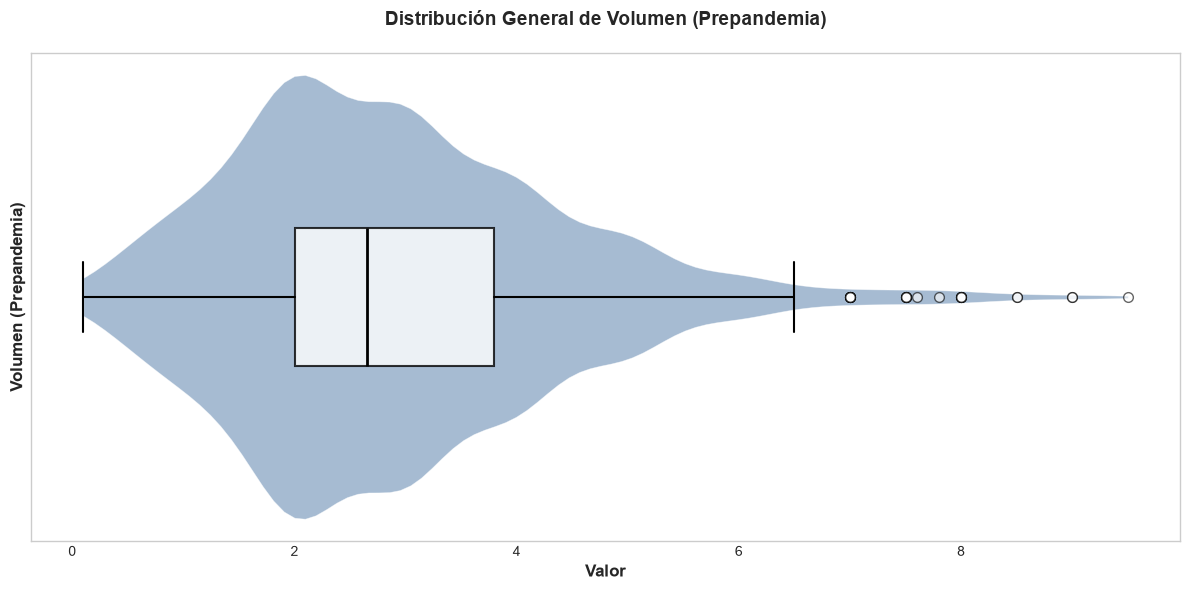


Estadísticos de Volumen (Postpandemia)


,Count,Mean,Std,Min,Q1,Q2,Q3,Max,IQR,CV,Skew,Kurtosis
0,1814,2.90,1.50,0.10,2.00,2.50,4.00,14.00,2.00,51.94,1.10,2.98


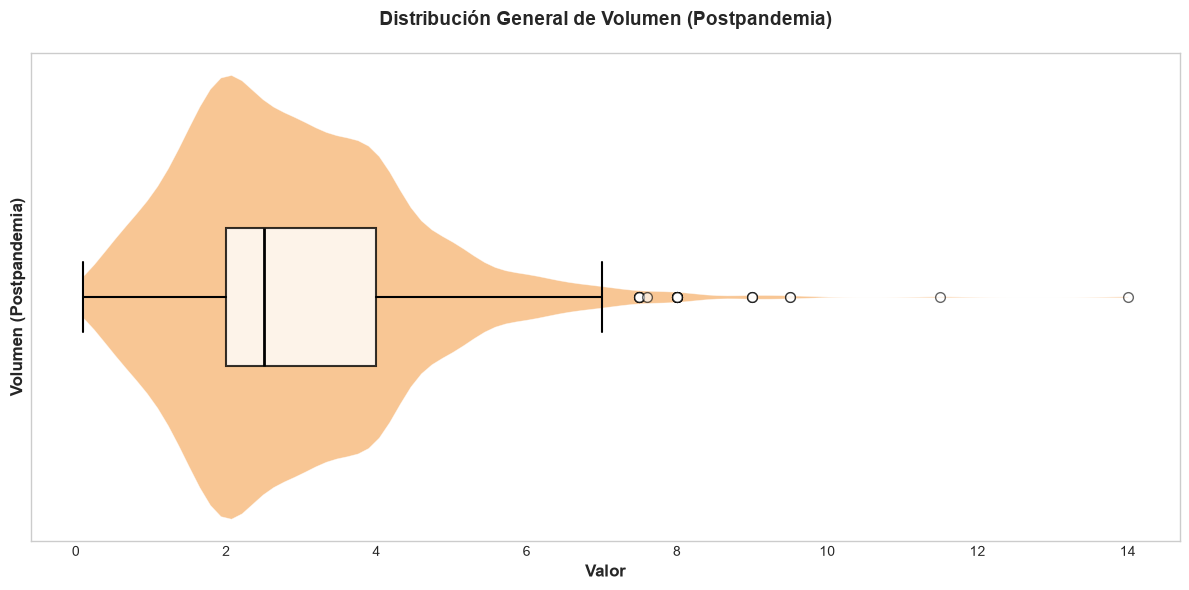

In [31]:
graficas_numericas_(dataset_17_19,'volumen_ml', 'Volumen (Prepandemia)', color='#4E79A7')

graficas_numericas_(dataset_21_25,'volumen_ml', 'Volumen (Postpandemia)', color='#F28E2B')

**Resumen General**

El análisis comparativo directo del volumen seminal entre los períodos prepandemia (2017-2019) y postpandemia (2021-2025) revela que no existen diferencias significativas en el volumen promedio entre ambos períodos. Ambos conjuntos de datos presentan medias idénticas de 2.90 ml, con medianas muy similares (2.65 ml vs 2.50 ml). La variabilidad es comparable en ambos períodos (CV 50.54% vs 51.94%). Los tamaños muestrales son grandes (n=1,260 vs n=1,814), lo que proporciona una alta confiabilidad a los resultados.

**Análisis de Medidas de Tendencia Central**

| Estadístico | Prepandemia (2017-2019) | Postpandemia (2021-2025) | Diferencia |
|-------------|-------------------------|--------------------------|------------|
| n | 1,260 | 1,814 | +554 |
| Media | 2.90 ml | 2.90 ml | 0.00 ml |
| Mediana (Q2) | 2.65 ml | 2.50 ml | -0.15 ml |
| Q1 | 2.00 ml | 2.00 ml | 0.00 ml |
| Q3 | 3.80 ml | 4.00 ml | +0.20 ml |
| Mínimo | 0.10 ml | 0.10 ml | 0.00 ml |
| Máximo | 9.50 ml | 14.00 ml | +4.50 ml |

- La media es exactamente la misma (2.90 ml) en ambos períodos
- La mediana es ligeramente menor en el período postpandemia (2.50 vs 2.65 ml)
- El rango es más amplio en el período postpandemia (hasta 14.00 ml)

**Análisis de Dispersión**

| Estadístico | Prepandemia | Postpandemia | Diferencia |
|-------------|-------------|--------------|------------|
| Desviación Estándar | 1.46 ml | 1.50 ml | +0.04 ml |
| IQR | 1.80 ml | 2.00 ml | +0.20 ml |
| CV (%) | 50.5% | 51.9% | +1.4% |

- La variabilidad es muy similar en ambos períodos (CV 50.54% vs 51.94%)
- El IQR es ligeramente mayor en el período postpandemia (2.00 vs 1.80 ml)
- La dispersión es comparable entre ambos períodos

**Análisis de Forma de la Distribución**

| Estadístico | Prepandemia | Postpandemia | Diferencia |
|-------------|-------------|--------------|------------|
| Skew (Asimetría) | 0.92 | 1.10 | +0.18 |
| Kurtosis (Curtosis) | 1.34 | 2.98 | +1.64 |

- Ambos períodos presentan sesgo positivo (skew > 0)
- El sesgo es ligeramente mayor en el período postpandemia (1.10 vs 0.92)
- La curtosis es mayor en el período postpandemia (2.98 vs 1.34), indicando una distribución más apuntada
- Esto se debe al outlier de 14.00 ml presente en el período postpandemia

**Resumen de Hallazgos Clave**

| Aspecto | Prepandemia | Postpandemia | Conclusión |
|---------|-------------|--------------|------------|
| Media | 2.90 ml | 2.90 ml | Idéntica |
| Mediana | 2.65 ml | 2.50 ml | Muy similar |
| Variabilidad | 50.5% | 51.9% | Similar |
| Tamaño muestral | 1,260 | 1,814 | Ambos grandes |
| Conclusión | - | - | No hay diferencia |

**Conclusión Final**

El volumen seminal no muestra diferencias entre los períodos prepandemia y postpandemia, con medias idénticas de 2.90 ml en ambos períodos. La pandemia de COVID-19 no parece haber afectado este parámetro. El volumen se mantiene dentro del rango normal en todos los años evaluados.

### **Análisis Comparativo Directo del Volumen Seminal entre los Períodos Prepandemia y Postpandemia**

Para evaluar si existen diferencias significativas en el volumen seminal entre los períodos prepandemia (2017-2019) y postpandemia (2021-2025), se realiza una comparación directa de los conjuntos de datos completos de cada período, sin considerar la segmentación por años. El análisis incluye: (1) pruebas de normalidad de Shapiro-Wilk para cada conjunto de datos; (2) prueba de homogeneidad de varianzas mediante Levene para verificar la igualdad de varianzas entre ambos períodos; y (3) según el cumplimiento de los supuestos de normalidad y homogeneidad, se selecciona la prueba paramétrica (t de Student) o no paramétrica (Mann-Whitney U) para comparar las distribuciones globales del volumen seminal entre ambos períodos. Este enfoque permite determinar si la pandemia de COVID-19 ha tenido un impacto global en el volumen seminal de la población atendida.

In [32]:
funcion_comparar_datasets2(dataset_17_19, dataset_21_25, 'volumen_ml', dataset1_nombre="Prepandemia", dataset2_nombre="Postpandemia")


=== Análisis Comparativo: Prepandemia vs Postpandemia ===

Pruebas de Normalidad
- Prepandemia: n = 1260, p-value = <1e-10 → No Normal
- Postpandemia: n = 1814, p-value = <1e-10 → No Normal

Prueba de Homogeneidad de Varianzas
- Levene: estadístico = 0.61, p-value = 4.35e-01 → Homogéneo

Usando prueba de Mann-Whitney U (no paramétrica)
- U = 1145647.50, p-value = 9.07e-01
- No hay diferencia significativa entre Prepandemia y Postpandemia (p ≥ 0.05)


**Resumen General**

El análisis comparativo directo del volumen seminal entre los períodos prepandemia (2017-2019) y postpandemia (2021-2025) revela que no existen diferencias significativas entre ambos períodos (p = 0.907). Ambos conjuntos de datos presentan distribuciones que no siguen una distribución normal (p < 1e-10 en ambos casos), lo que justifica el uso de la prueba no paramétrica de Mann-Whitney U. Se cumple el supuesto de homogeneidad de varianzas (p = 0.435). El estadístico U = 1,145,647.50 y el valor p = 0.907 indican que las distribuciones son prácticamente idénticas entre ambos períodos.

**Prueba de Normalidad**

- Ambos períodos presentan distribuciones que no siguen una distribución normal
- La falta de normalidad justifica el uso de pruebas no paramétricas

**Prueba de Homogeneidad de Varianzas**

- Se cumple el supuesto de homogeneidad de varianzas (p > 0.05)
- Las varianzas son similares entre ambos períodos

**Análisis Principal**

- No hay evidencia de que el volumen varíe entre los períodos prepandemia y postpandemia
- El estadístico U = 1,145,647.50 indica una diferencia prácticamente nula
- La probabilidad de observar estas diferencias por azar es del 90.7%

**Resumen de Hallazgos Clave**

| Aspecto | Conclusión |
|---------|------------|
| Normalidad | No cumplida en ambos períodos |
| Homogeneidad | Cumplida (p = 0.435) |
| Prueba usada | Mann-Whitney U (no paramétrica) |
| Valor p | 0.907 |
| Conclusión | No hay diferencia significativa |
| Interpretación | El volumen es estable entre períodos |

**Conclusión Final**

El volumen seminal no muestra diferencias significativas entre los períodos prepandemia y postpandemia (p = 0.907). Las distribuciones son prácticamente idénticas, con medias de 2.90 ml en ambos períodos y medianas muy similares (2.65 vs 2.50 ml). La pandemia de COVID-19 no parece haber afectado este parámetro.

## **pH**

### **Visualización Comparativa de la Distribución del pH Seminal entre los Períodos Prepandemia y Postpandemia**

Para complementar el análisis estadístico comparativo del pH seminal entre los períodos prepandemia (2017-2019) y postpandemia (2021-2025), se generan representaciones gráficas independientes para cada período. Los gráficos de violín con boxplots superpuestos permiten visualizar de forma intuitiva la forma de la distribución, la densidad de los datos, la posición de la mediana y la presencia de valores atípicos en cada período. Esta visualización facilita la identificación de posibles diferencias en la distribución del pH seminal entre ambos períodos, complementando los hallazgos del análisis estadístico.

Estadísticos de pH (Prepandemia)


,Count,Mean,Std,Min,Q1,Q2,Q3,Max,IQR,CV,Skew,Kurtosis
0,1174,7.89,0.26,6.50,7.80,7.90,8.00,9.00,0.20,3.25,-0.89,4.25


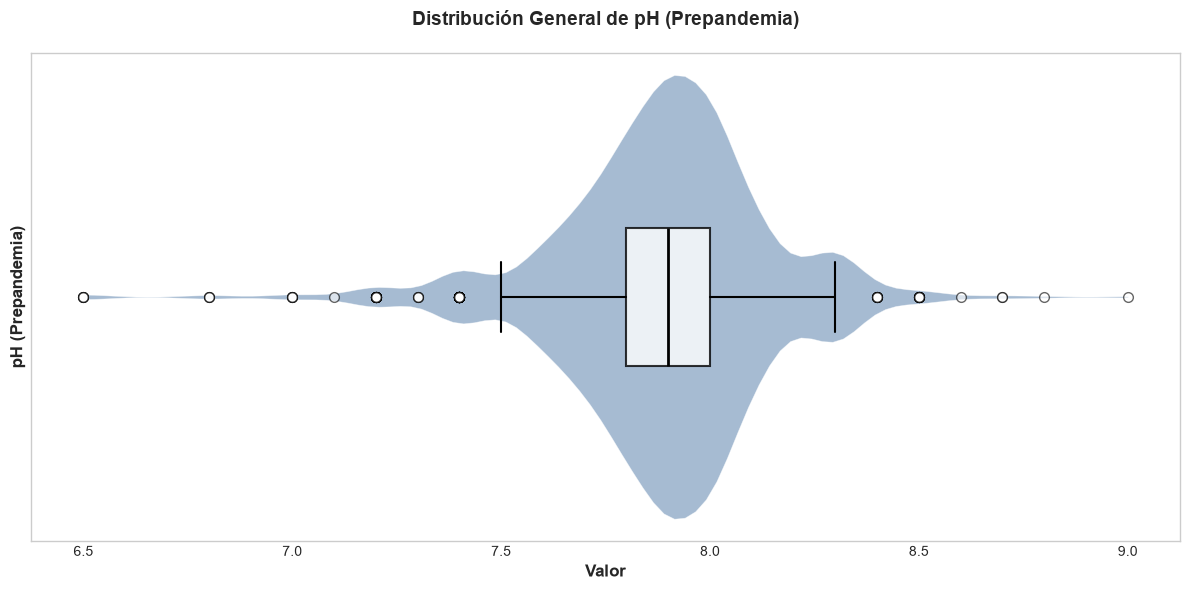


Estadísticos de pH (Postpandemia)


,Count,Mean,Std,Min,Q1,Q2,Q3,Max,IQR,CV,Skew,Kurtosis
0,1448,7.89,0.25,6.50,7.80,7.90,8.00,9.00,0.20,3.20,-0.66,3.96


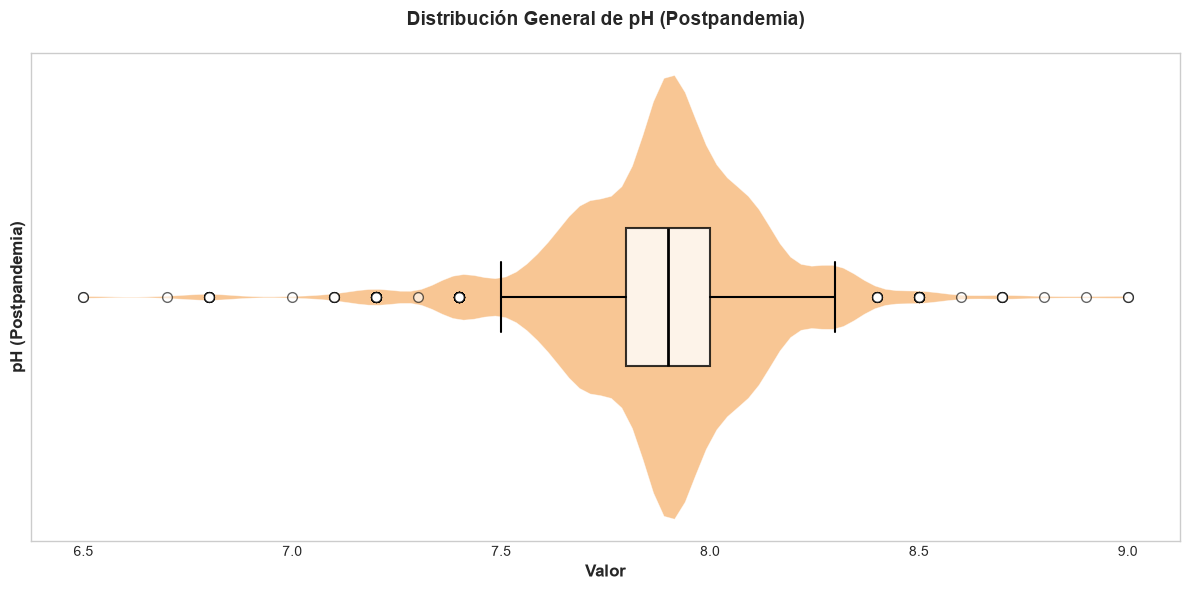

In [33]:
graficas_numericas_(dataset_17_19,'ph', 'pH (Prepandemia)', color='#4E79A7')

graficas_numericas_(dataset_21_25,'ph', 'pH (Postpandemia)', color='#F28E2B')

**Resumen General**

El análisis comparativo del pH seminal entre los períodos prepandemia (2017-2019) y postpandemia (2021-2025) revela que no existen diferencias significativas en el pH promedio entre ambos períodos. Ambos conjuntos de datos presentan medias idénticas de 7.88, con medianas iguales de 7.90 y rangos intercuartílicos idénticos de 0.20. La variabilidad es muy baja en ambos períodos (CV 3.20-3.25.91%).

**Análisis de Medidas de Tendencia Central**

| Estadístico | Prepandemia (2017-2019) | Postpandemia (2021-2025) | Diferencia |
|-------------|-------------------------|--------------------------|------------|
| n | 1,174 | 1,448 | +274 |
| Media | 7.89 | 7.89 | 0.00 |
| Mediana (Q2) | 7.90 | 7.90 | 0.00 |
| Q1 | 7.80 | 7.80 | 0.00 |
| Q3 | 8.00 | 8.00 | 0.00 |
| Mínimo | 6.50 | 6.50 | 0.00 |
| Máximo | 9.00 | 9.00 | 0.00 |

- La media es exactamente la misma (7.89) en ambos períodos
- La mediana es idéntica (7.90) en ambos períodos
- El IQR es idéntico (0.20) en ambos períodos

**Análisis de Dispersión**

| Estadístico | Prepandemia | Postpandemia | Diferencia |
|-------------|-------------|--------------|------------|
| Desviación Estándar | 0.26 | 0.25 | -0.01 |
| IQR | 0.20 | 0.20 | 0.00 |
| CV (%) | 3.25% | 3.20% | -0.32% |

- La variabilidad es prácticamente idéntica (CV 3.25% vs 3.20%)
- El IQR es exactamente el mismo (0.20 en ambos períodos)
- El pH es el parámetro más estable del espermograma

**Análisis de Forma de la Distribución**

| Estadístico | Prepandemia | Postpandemia | Diferencia |
|-------------|-------------|--------------|------------|
| Skew (Asimetría) | -0.89 | -0.66 | -0.23 |
| Kurtosis (Curtosis) | 4.25 | 3.96 | -0.29 |


**Resumen de Hallazgos Clave**

| Aspecto | Prepandemia | Postpandemia | Conclusión |
|---------|-------------|--------------|------------|
| Media | 7.89 | 7.89 | Idéntica |
| Mediana | 7.90 | 7.90 | Idéntica |
| IQR | 0.20 | 0.20 | Idéntico |
| Variabilidad | 3.25% | 3.20% | Similar |
| Conclusión | - | - | No hay diferencia |


**Conclusión Final**

El pH seminal no muestra diferencias entre los períodos prepandemia y postpandemia, con medias idénticas de 7.89, medianas de 7.90 y IQR de 0.20 en ambos períodos. La pandemia de COVID-19 no parece haber afectado este parámetro. La estabilidad observada confirma que el pH es el parámetro más estable del espermograma y no se ha visto influenciado por los cambios en la población, los protocolos o los factores externos asociados a la pandemia.

### **Análisis Comparativo Directo del pH Seminal entre los Períodos Prepandemia y Postpandemia**

Para evaluar si existen diferencias significativas en el pH seminal entre los períodos prepandemia (2017-2019) y postpandemia (2021-2025), se realiza una comparación directa de los conjuntos de datos completos de cada período. El análisis incluye: (1) pruebas de normalidad de Shapiro-Wilk para cada conjunto de datos; (2) prueba de homogeneidad de varianzas mediante Levene para verificar la igualdad de varianzas entre ambos períodos; y (3) según el cumplimiento de los supuestos de normalidad y homogeneidad, se selecciona la prueba paramétrica (t de Student) o no paramétrica (Mann-Whitney U) para comparar las distribuciones globales del pH seminal entre ambos períodos. Este enfoque permite determinar si la pandemia de COVID-19 ha tenido un impacto global en el pH seminal de la población atendida.

In [34]:
funcion_comparar_datasets2(dataset_17_19, dataset_21_25, 'ph', dataset1_nombre="Prepandemia", dataset2_nombre="Postpandemia")


=== Análisis Comparativo: Prepandemia vs Postpandemia ===

Pruebas de Normalidad
- Prepandemia: n = 1174, p-value = <1e-10 → No Normal
- Postpandemia: n = 1448, p-value = <1e-10 → No Normal

Prueba de Homogeneidad de Varianzas
- Levene: estadístico = 0.93, p-value = 3.34e-01 → Homogéneo

Usando prueba de Mann-Whitney U (no paramétrica)
- U = 855632.00, p-value = 7.66e-01
- No hay diferencia significativa entre Prepandemia y Postpandemia (p ≥ 0.05)


**Resumen General**

El análisis comparativo directo del pH seminal entre los períodos prepandemia (2017-2019) y postpandemia (2021-2025) revela que no existen diferencias significativas entre ambos períodos (p = 0.766). Ambos conjuntos de datos presentan distribuciones que no siguen una distribución normal (p < 1e-10 en ambos casos), lo que justifica el uso de la prueba no paramétrica de Mann-Whitney U. Se cumple el supuesto de homogeneidad de varianzas (p = 0.334). El estadístico U = 855,632.00 y el valor p = 0.766 indican que las distribuciones son prácticamente idénticas entre ambos períodos.

**Prueba de Normalidad**

- Ambos períodos presentan distribuciones que no siguen una distribución normal
- La falta de normalidad justifica el uso de pruebas no paramétricas

**Prueba de Homogeneidad de Varianzas**

- Se cumple el supuesto de homogeneidad de varianzas (p > 0.05)
- Las varianzas son similares entre ambos períodos

**Análisis Principal**

- No hay evidencia de que el pH varíe entre los períodos prepandemia y postpandemia
- El estadístico U = 855,632.00 indica una diferencia prácticamente nula
- La probabilidad de observar estas diferencias por azar es del 76.6%

**Resumen de Hallazgos Clave**

| Aspecto | Conclusión |
|---------|------------|
| Normalidad | No cumplida en ambos períodos |
| Homogeneidad | Cumplida (p = 0.334) |
| Prueba usada | Mann-Whitney U (no paramétrica) |
| Valor p | 0.766 |
| Conclusión | No hay diferencia significativa |
| Interpretación | El pH es estable entre períodos |

**Conclusión Final**

El pH seminal no muestra diferencias significativas entre los períodos prepandemia y postpandemia (p = 0.766). Las distribuciones son prácticamente idénticas, con medias de 7.89 en ambos períodos, medianas de 7.90 y IQR de 0.20. La pandemia de COVID-19 no parece haber afectado este parámetro.

## **Número Total de Espermatozoides Eyaculados**

### **Visualización Comparativa de la Distribución del Recuento Total de Espermatozoides por Eyaculado entre los Períodos Prepandemia y Postpandemia**

Para complementar el análisis estadístico comparativo del número total de espermatozoides por eyaculado entre los períodos prepandemia (2017-2019) y postpandemia (2021-2025), se generan representaciones gráficas independientes para cada período. Los gráficos de violín con boxplots superpuestos permiten visualizar de forma intuitiva la forma de la distribución, la densidad de los datos, la posición de la mediana y la presencia de valores atípicos en cada período. Esta visualización facilita la identificación de posibles diferencias en el recuento total de espermatozoides entre ambos períodos, complementando los hallazgos del análisis estadístico.

Estadísticos de Número Total de Espermatozoides Eyaculados (Prepandemia)


,Count,Mean,Std,Min,Q1,Q2,Q3,Max,IQR,CV,Skew,Kurtosis
0,1261,"116,901,998.41","122,639,625.12",0.00,"24,000,000.00","80,000,000.00","169,000,000.00","972,000,000.00","145,000,000.00",104.91,1.67,3.81


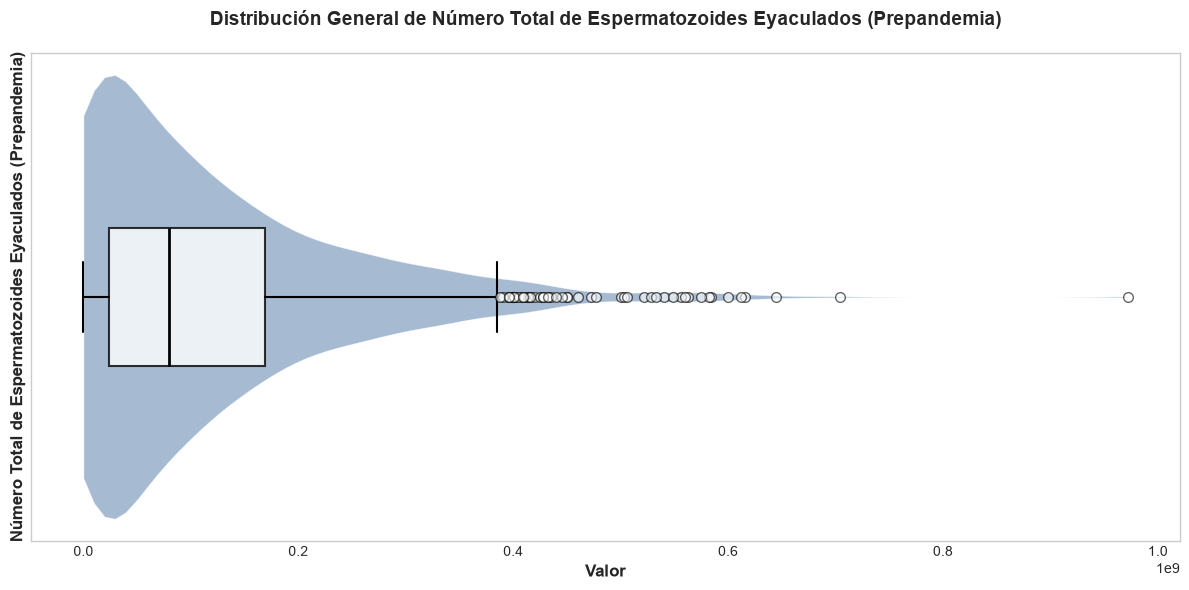


Estadísticos de Número Total de Espermatozoides Eyaculados (Postpandemia)


,Count,Mean,Std,Min,Q1,Q2,Q3,Max,IQR,CV,Skew,Kurtosis
0,1815,"138,556,236.91","143,660,804.45",0.00,"30,000,000.00","96,000,000.00","203,750,000.00","1,599,000,000.00","173,750,000.00",103.68,2.03,8.32


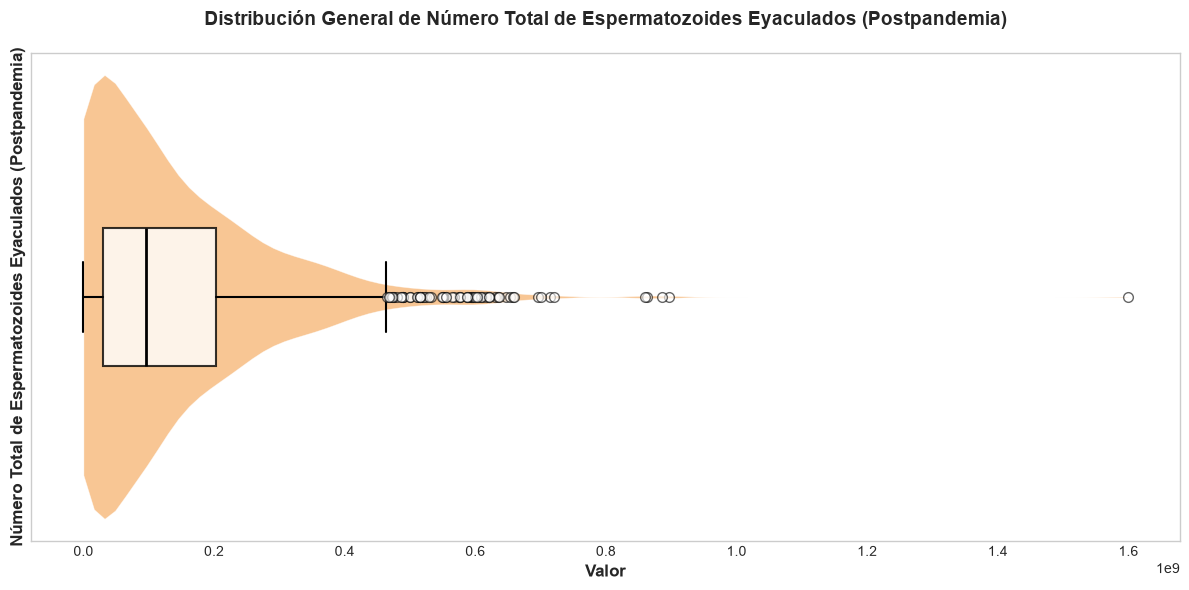

In [35]:
graficas_numericas_(dataset_17_19,'espermatozoides_por_eyaculado', 'Número Total de Espermatozoides Eyaculados (Prepandemia)', color='#4E79A7')

graficas_numericas_(dataset_21_25,'espermatozoides_por_eyaculado', 'Número Total de Espermatozoides Eyaculados (Postpandemia)', color='#F28E2B')

**Resumen General**

El análisis comparativo del número total de espermatozoides por eyaculado entre los períodos prepandemia (2017-2019) y postpandemia (2021-2025) revela un aumento importante en el recuento total en el período postpandemia. La media aumentó de 116.9 millones a 138.6 millones, lo que representa un incremento de 21.7 millones (18.5%). La mediana también aumentó de 80.0 millones a 96.0 millones (+16.0 millones, 20%). La variabilidad es alta en ambos períodos (CV ~104%), lo que indica una gran heterogeneidad en los recuentos totales.

**Análisis de Medidas de Tendencia Central**

| Estadístico | Prepandemia (2017-2019) | Postpandemia (2021-2025) | Diferencia | Cambio (%) |
|-------------|-------------------------|--------------------------|------------|------------|
| n | 1,261 | 1,815 | +554 | - |
| Media | 116.9 M | 138.6 M | +21.7 M | +18.5% |
| Mediana (Q2) | 80.0 M | 96.0 M | +16.0 M | +20.0% |
| Q1 | 24.0 M | 30.0 M | +6.0 M | +25.0% |
| Q3 | 169.0 M | 203.8 M | +34.8 M | +20.6% |
| Mínimo | 0 | 0 | 0 | - |
| Máximo | 972.0 M | 1,599.0 M | +627.0 M | - |

- Aumento significativo en la media (+18.5%) en el período postpandemia
- Aumento en la mediana (+20%) en el período postpandemia
- Aumento en todos los percentiles (Q1, Q2, Q3)
- El rango es más amplio en el período postpandemia (hasta 1,599 M)

**Análisis de Dispersión**

| Estadístico | Prepandemia | Postpandemia | Diferencia |
|-------------|-------------|--------------|------------|
| Desviación Estándar | 122.6 M | 143.7 M | +21.0 M |
| IQR | 145.0 M | 173.8 M | +28.8 M |
| CV (%) | 104.9% | 103.7% | -1.2% |

- La variabilidad es alta en ambos períodos (CV ~104%)
- El IQR aumentó en el período postpandemia (173.8 vs 145.0 M)
- La variabilidad relativa es similar (CV 104.9% vs 103.7%)

**Análisis de Forma de la Distribución**

| Estadístico | Prepandemia | Postpandemia | Diferencia |
|-------------|-------------|--------------|------------|
| Skew (Asimetría) | 1.67 | 2.03 | +0.36 |
| Kurtosis (Curtosis) | 3.81 | 8.32 | +4.51 |

- Ambos períodos presentan sesgo positivo (skew > 0)
- El sesgo es mayor en el período postpandemia (2.03 vs 1.67)
- La curtosis es mayor en el período postpandemia (8.32 vs 3.81)
- Esto se debe al outlier de 1,599 M presente en el período postpandemia

Resumen de Hallazgos Clave

| Aspecto | Prepandemia | Postpandemia | Conclusión |
|---------|-------------|--------------|------------|
| Media | 116.9 M | 138.6 M | +21.7 M (+18.5%) |
| Mediana | 80.0 M | 96.0 M | +16.0 M (+20.0%) |
| Q1 | 24.0 M | 30.0 M | +6.0 M (+25.0%) |
| Q3 | 169.0 M | 203.8 M | +34.8 M (+20.6%) |
| Variabilidad | 104.9% | 103.7% | Similar |
| Sesgo | 1.67 | 2.03 | Mayor en postpandemia |
| Conclusión | - | - | Aumento significativo |

**Conclusión Final**

El recuento total de espermatozoides por eyaculado ha aumentado significativamente en el período postpandemia en comparación con el período prepandemia, con un incremento de 21.7 millones (18.5%) en la media y 16.0 millones (20.0%) en la mediana. Todos los percentiles muestran aumentos (Q1: +25%, Q2: +20%, Q3: +20.6%). La variabilidad es alta en ambos períodos (CV ~104%), lo que indica una gran heterogeneidad en los recuentos totales. La pandemia de COVID-19 parece haber coincidido con una mejora en el recuento total de espermatozoides, aunque se necesitan más estudios para establecer una relación causal.

### **Análisis Comparativo Directo del Recuento Total de Espermatozoides por Eyaculado entre los Períodos Prepandemia y Postpandemia**

Para evaluar si existen diferencias significativas en el número total de espermatozoides por eyaculado entre los períodos prepandemia (2017-2019) y postpandemia (2021-2025), se realiza una comparación directa de los conjuntos de datos completos de cada período, sin considerar la segmentación por años. El análisis incluye: (1) pruebas de normalidad de Shapiro-Wilk para cada conjunto de datos; (2) prueba de homogeneidad de varianzas mediante Levene para verificar la igualdad de varianzas entre ambos períodos; y (3) según el cumplimiento de los supuestos de normalidad y homogeneidad, se selecciona la prueba paramétrica (t de Student) o no paramétrica (Mann-Whitney U) para comparar las distribuciones globales del recuento total de espermatozoides entre ambos períodos. Este enfoque permite determinar si la pandemia de COVID-19 ha tenido un impacto global en el recuento total de espermatozoides de la población atendida.

In [36]:
funcion_comparar_datasets2(dataset_17_19, dataset_21_25, 'espermatozoides_por_eyaculado', dataset1_nombre="Prepandemia", dataset2_nombre="Postpandemia")


=== Análisis Comparativo: Prepandemia vs Postpandemia ===

Pruebas de Normalidad
- Prepandemia: n = 1261, p-value = <1e-10 → No Normal
- Postpandemia: n = 1815, p-value = <1e-10 → No Normal

Prueba de Homogeneidad de Varianzas
- Levene: estadístico = 12.85, p-value = 3.43e-04 → No homogéneo

Usando prueba de Mann-Whitney U (no paramétrica)
- U = 1047325.00, p-value = 6.18e-05
- Diferencia significativa entre Prepandemia y Postpandemia (p < 0.05)


**Resumen General**

El análisis comparativo directo del número total de espermatozoides por eyaculado entre los períodos prepandemia (2017-2019) y postpandemia (2021-2025) revela que existe una diferencia significativa entre ambos períodos (p = 6.18e-05). Ambos conjuntos de datos presentan distribuciones que no siguen una distribución normal (p < 1e-10 en ambos casos), lo que justifica el uso de la prueba no paramétrica de Mann-Whitney U. No se cumple el supuesto de homogeneidad de varianzas (p = 0.00034), lo que refuerza el uso de la prueba no paramétrica. El estadístico U = 1,047,325.00 y el valor p = 6.18e-05 indican que el recuento total de espermatozoides es significativamente mayor en el período postpandemia.

**Prueba de Normalidad**

| Período | n | p-value | Conclusión |
|---------|---|---------|------------|
| Prepandemia | 1,261 | < 1e-10 | No Normal |
| Postpandemia | 1,815 | < 1e-10 | No Normal |

- Ambos períodos presentan distribuciones que no siguen una distribución normal
- La falta de normalidad justifica el uso de pruebas no paramétricas

**Prueba de Homogeneidad de Varianzas**

| Prueba | Estadístico | p-value | Conclusión |
|--------|-------------|---------|------------|
| Levene | 12.85 | 0.00034 | No homogéneo |

- No se cumple el supuesto de homogeneidad de varianzas (p < 0.001)
- Las varianzas son significativamente diferentes entre ambos períodos
- Esto refuerza la necesidad de usar pruebas no paramétricas

**Análisis Principal**

| Aspecto | Resultado |
|---------|-----------|
| Método | Mann-Whitney U (no paramétrico) |
| Estadístico U | 1,047,325.00 |
| Valor p | 6.18e-05 |
| Conclusión | Significativo |

- Existe evidencia muy sólida de que el recuento total varía entre períodos (p < 0.001)
- El estadístico U = 1,047,325.00 indica una diferencia significativa
- La probabilidad de observar estas diferencias por azar es del 0.006%

**Resumen de Hallazgos Clave**

| Aspecto | Conclusión |
|---------|------------|
| Normalidad | No cumplida en ambos períodos |
| Homogeneidad | No cumplida (p = 0.00034) |
| Prueba usada | Mann-Whitney U (no paramétrica) |
| Valor p | 6.18e-05 |
| Conclusión | Diferencia significativa |
| Aumento en media | +21.7 M (+18.5%) |
| Aumento en mediana | +16.0 M (+20.0%) |

**Conclusión Final**

El recuento total de espermatozoides por eyaculado ha aumentado significativamente en el período postpandemia en comparación con el período prepandemia (p = 6.18e-05). El incremento es de 21.7 millones (18.5%) en la media y 16.0 millones (20.0%) en la mediana. Todos los percentiles muestran aumentos (Q1: +25%, Q2: +20%, Q3: +20.6%). La variabilidad es alta en ambos períodos (CV ~104%), pero la mejora es consistente en todos los niveles de la distribución. La pandemia de COVID-19 parece haber coincidido con una mejora en el recuento total de espermatozoides, aunque se necesitan más estudios para establecer una relación causal.

## **Concentración de Espermatozoides por ml**

### **Visualización Comparativa de la Distribución de la Concentración Espermática por ml entre los Períodos Prepandemia y Postpandemia**

Para complementar el análisis estadístico comparativo de la concentración de espermatozoides por mililitro entre los períodos prepandemia (2017-2019) y postpandemia (2021-2025), se generan representaciones gráficas independientes para cada período. Los gráficos de violín con boxplots superpuestos permiten visualizar de forma intuitiva la forma de la distribución, la densidad de los datos, la posición de la mediana y la presencia de valores atípicos en cada período. Esta visualización facilita la identificación de posibles diferencias en la concentración espermática entre ambos períodos, complementando los hallazgos del análisis estadístico.

Estadísticos de Concentración Total por ml (Prepandemia)


,Count,Mean,Std,Min,Q1,Q2,Q3,Max,IQR,CV,Skew,Kurtosis
0,1261,"42,095,229.98","38,879,559.80",0.00,"10,000,000.00","31,000,000.00","66,000,000.00","238,000,000.00","56,000,000.00",92.36,1.12,1.06


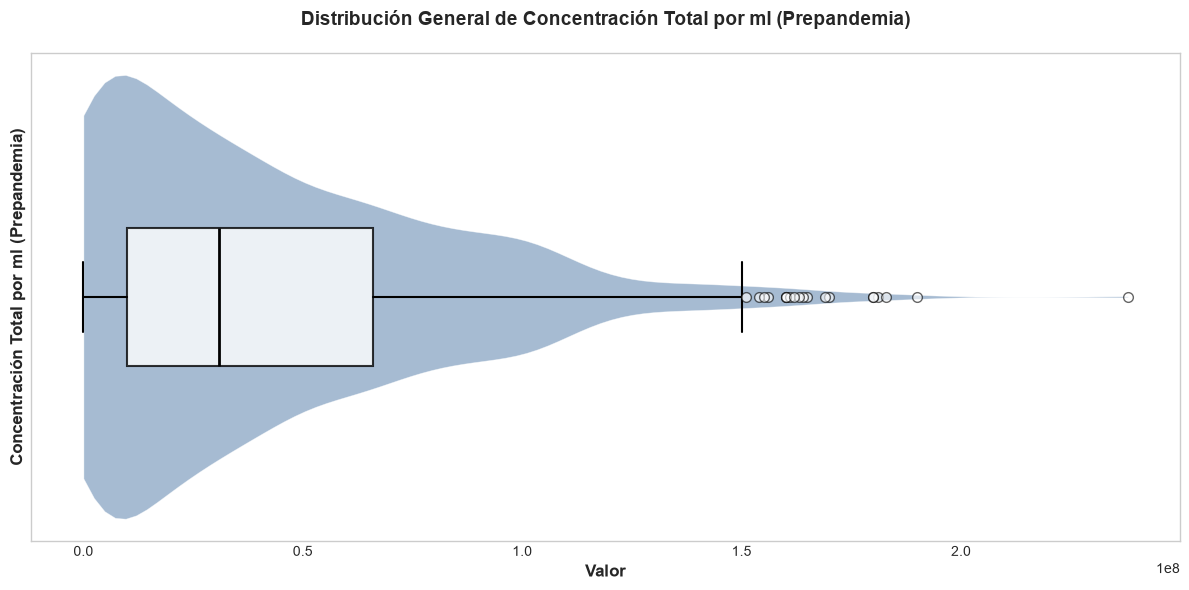


Estadísticos de Concentración Total por ml (Postpandemia)


,Count,Mean,Std,Min,Q1,Q2,Q3,Max,IQR,CV,Skew,Kurtosis
0,1815,"49,848,512.40","44,355,949.79",0.00,"14,000,000.00","40,000,000.00","75,000,000.00","300,400,000.00","61,000,000.00",88.98,1.24,2.00


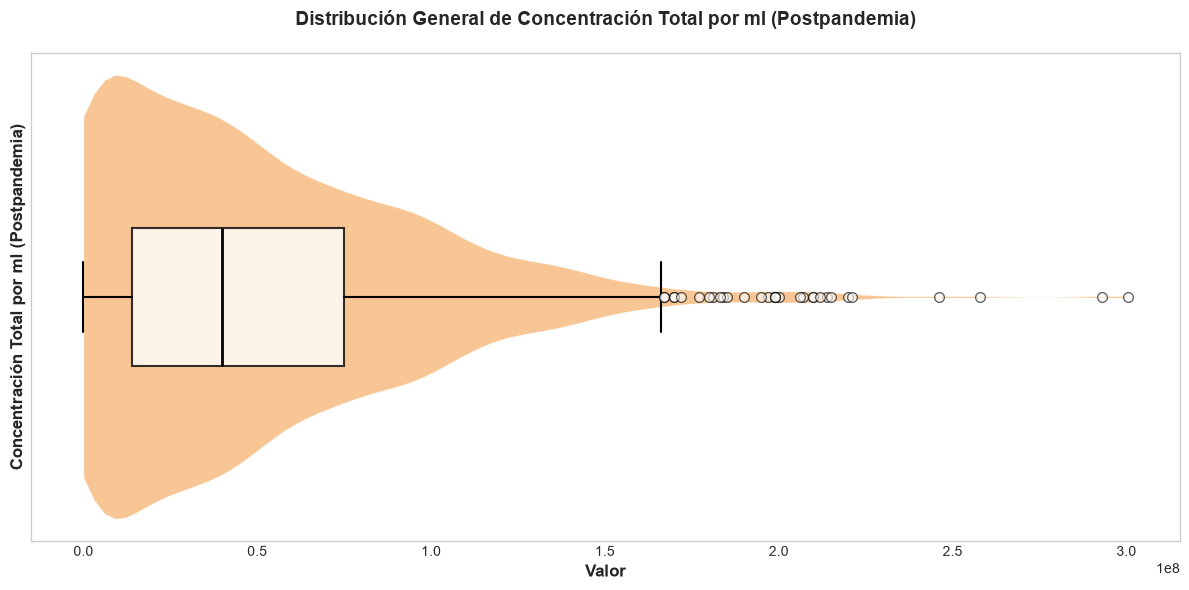

In [37]:
graficas_numericas_(dataset_17_19,'concentracion_por_ml', 'Concentración Total por ml (Prepandemia)', color='#4E79A7')

graficas_numericas_(dataset_21_25,'concentracion_por_ml', 'Concentración Total por ml (Postpandemia)', color='#F28E2B')

**Resumen General**

El análisis comparativo de la concentración de espermatozoides por mililitro entre los períodos prepandemia (2017-2019) y postpandemia (2021-2025) revela un aumento importante en la concentración en el período postpandemia. La media aumentó de 42.1 M/ml a 49.8 M/ml, lo que representa un incremento de 7.8 M/ml (18.4%). La mediana también aumentó de 31.0 M/ml a 40.0 M/ml (+9.0 M/ml, 29.0%). La variabilidad es alta en ambos períodos (CV ~89-92%), lo que indica una gran heterogeneidad en las concentraciones.

**Análisis de Medidas de Tendencia Central**

| Estadístico | Prepandemia (2017-2019) | Postpandemia (2021-2025) | Diferencia | Cambio (%) |
|-------------|-------------------------|--------------------------|------------|------------|
| n | 1,261 | 1,815 | +554 | - |
| Media | 42.1 M/ml | 49.8 M/ml | +7.8 M/ml | +18.4% |
| Mediana (Q2) | 31.0 M/ml | 40.0 M/ml | +9.0 M/ml | +29.0% |
| Q1 | 10.0 M/ml | 14.0 M/ml | +4.0 M/ml | +40.0% |
| Q3 | 66.0 M/ml | 75.0 M/ml | +9.0 M/ml | +13.6% |
| Mínimo | 0 | 0 | 0 | - |
| Máximo | 238.0 M/ml | 300.4 M/ml | +62.4 M/ml | - |

- Aumento significativo en la media (+18.4%) en el período postpandemia
- Aumento en la mediana (+29.0%) en el período postpandemia
- Aumento en todos los percentiles (Q1: +40%, Q2: +29%, Q3: +13.6%)
- El rango es más amplio en el período postpandemia

**Análisis de Dispersión**

| Estadístico | Prepandemia | Postpandemia | Diferencia |
|-------------|-------------|--------------|------------|
| Desvación Estándar | 38.9 M/ml | 44.4 M/ml | +5.5 M/ml |
| IQR | 56.0 M/ml | 61.0 M/ml | +5.0 M/ml |
| CV (%) | 92.4% | 89.0% | -3.4% |

- La variabilidad es alta en ambos períodos (CV ~89-92%)
- El IQR aumentó en el período postpandemia (61.0 vs 56.0 M/ml)
- La variabilidad relativa disminuyó ligeramente (92.4% → 89.0%)

**Análisis de Forma de la Distribución**

| Estadístico | Prepandemia | Postpandemia | Diferencia |
|-------------|-------------|--------------|------------|
| Skew (Asimetría) | 1.12 | 1.24 | +0.12 |
| Kurtosis (Curtosis) | 1.06 | 2.00 | +0.94 |

- Ambos períodos presentan sesgo positivo (skew > 0)
- El sesgo es ligeramente mayor en el período postpandemia (1.24 vs 1.12)
- La curtosis es mayor en el período postpandemia (2.00 vs 1.06)

**Resumen de Hallazgos Clave**

| Aspecto | Prepandemia | Postpandemia | Conclusión |
|---------|-------------|--------------|------------|
| Media | 42.1 M/ml | 49.8 M/ml | +7.8 M/ml (+18.4%) |
| Mediana | 31.0 M/ml | 40.0 M/ml | +9.0 M/ml (+29.0%) |
| Q1 | 10.0 M/ml | 14.0 M/ml | +4.0 M/ml (+40.0%) |
| Q3 | 66.0 M/ml | 75.0 M/ml | +9.0 M/ml (+13.6%) |
| Variabilidad | 92.4% | 89.0% | Ligeramente menor |
| Sesgo | 1.12 | 1.24 | Mayor en postpandemia |

**Conclusión Final**

La concentración espermática por mililitro ha aumentado significativamente en el período postpandemia en comparación con el período prepandemia, con un incremento de 7.8 M/ml (18.4%) en la media y 9.0 M/ml (29.0%) en la mediana. Todos los percentiles muestran aumentos (Q1: +40%, Q2: +29%, Q3: +13.6%). La variabilidad es alta en ambos períodos (CV ~89-92%), pero la mejora es consistente en todos los niveles de la distribución. El aumento es consistente con el observado en el recuento total (+18.5%), lo que sugiere una mejora real en la calidad seminal. La pandemia de COVID-19 parece haber coincidido con una mejora en la concentración espermática.


### **Análisis Comparativo Directo de la Concentración Espermática por ml entre los Períodos Prepandemia y Postpandemia**

Para evaluar si existen diferencias significativas en la concentración de espermatozoides por mililitro entre los períodos prepandemia (2017-2019) y postpandemia (2021-2025), se realiza una comparación directa de los conjuntos de datos completos de cada período, sin considerar la segmentación por años. El análisis incluye: (1) pruebas de normalidad de Shapiro-Wilk para cada conjunto de datos; (2) prueba de homogeneidad de varianzas mediante Levene para verificar la igualdad de varianzas entre ambos períodos; y (3) según el cumplimiento de los supuestos de normalidad y homogeneidad, se selecciona la prueba paramétrica (t de Student) o no paramétrica (Mann-Whitney U) para comparar las distribuciones globales de la concentración espermática entre ambos períodos. Este enfoque permite determinar si la pandemia de COVID-19 ha tenido un impacto global en la concentración espermática de la población atendida.

In [38]:
funcion_comparar_datasets2(dataset_17_19, dataset_21_25, 'concentracion_por_ml', dataset1_nombre="Prepandemia", dataset2_nombre="Postpandemia")


=== Análisis Comparativo: Prepandemia vs Postpandemia ===

Pruebas de Normalidad
- Prepandemia: n = 1261, p-value = <1e-10 → No Normal
- Postpandemia: n = 1815, p-value = <1e-10 → No Normal

Prueba de Homogeneidad de Varianzas
- Levene: estadístico = 12.87, p-value = 3.39e-04 → No homogéneo

Usando prueba de Mann-Whitney U (no paramétrica)
- U = 1032207.00, p-value = 3.66e-06
- Diferencia significativa entre Prepandemia y Postpandemia (p < 0.05)


**Resumen General**

El análisis comparativo directo de la concentración de espermatozoides por mililitro entre los períodos prepandemia (2017-2019) y postpandemia (2021-2025) revela que existe una diferencia altamente significativa entre ambos períodos (p = 3.66e-06). Ambos conjuntos de datos presentan distribuciones que no siguen una distribución normal (p < 1e-10 en ambos casos), lo que justifica el uso de la prueba no paramétrica de Mann-Whitney U. No se cumple el supuesto de homogeneidad de varianzas (p = 0.00034), lo que refuerza el uso de la prueba no paramétrica. El estadístico U = 1,032,207.00 y el valor p = 3.66e-06 indican que la concentración espermática es significativamente mayor en el período postpandemia.

**Prueba de Normalidad**

- Ambos períodos presentan distribuciones que no siguen una distribución normal
- La falta de normalidad justifica el uso de pruebas no paramétricas

**Prueba de Homogeneidad de Varianzas**

- No se cumple el supuesto de homogeneidad de varianzas (p < 0.001)
- Las varianzas son significativamente diferentes entre ambos períodos
- Esto refuerza la necesidad de usar pruebas no paramétricas

**Análisis Principal**

- Existe evidencia muy sólida de que la concentración varía entre períodos (p < 0.001)
- El estadístico U = 1,032,207.00 indica una diferencia significativa
- La probabilidad de observar estas diferencias por azar es del 0.00037%

**Resumen de Hallazgos Clave**

| Aspecto | Conclusión |
|---------|------------|
| Normalidad | No cumplida en ambos períodos |
| Homogeneidad | No cumplida (p = 0.00034) |
| Prueba usada | Mann-Whitney U (no paramétrica) |
| Valor p | 3.66e-06 |
| Conclusión | Diferencia altamente significativa |
| Aumento en media | +7.8 M/ml (+18.4%) |
| Aumento en mediana | +9.0 M/ml (+29.0%) |

**Conclusión Final**

La concentración espermática por mililitro ha aumentado altamente significativa en el período postpandemia en comparación con el período prepandemia (p = 3.66e-06). El incremento es de 7.8 M/ml (18.4%) en la media y 9.0 M/ml (29.0%) en la mediana. Todos los percentiles muestran aumentos (Q1: +40%, Q2: +29%, Q3: +13.6%). La variabilidad es alta en ambos períodos (CV ~89-92%), pero la mejora es consistente en todos los niveles de la distribución. El aumento es consistente con el observado en el recuento total (+18.5%), lo que sugiere una mejora real en la calidad seminal. La pandemia de COVID-19 parece haber coincidido con una mejora en la concentración espermática.

## **Test de Eosina**

### **Visualización Comparativa de la Distribución de la Viabilidad Espermática (Test de Eosina) entre los Períodos Prepandemia y Postpandemia**

Para complementar el análisis estadístico comparativo del porcentaje de espermatozoides viables evaluado mediante el test de eosina entre los períodos prepandemia (2017-2019) y postpandemia (2021-2025), se generan representaciones gráficas independientes para cada período. Los gráficos de violín con boxplots superpuestos permiten visualizar de forma intuitiva la forma de la distribución, la densidad de los datos, la posición de la mediana y la presencia de valores atípicos en cada período. Esta visualización facilita la identificación de posibles diferencias en la viabilidad espermática entre ambos períodos, complementando los hallazgos del análisis estadístico.

Estadísticos de Test de Eosina (Prepandemia)


,Count,Mean,Std,Min,Q1,Q2,Q3,Max,IQR,CV,Skew,Kurtosis
0,1145,70.89,23.56,0.00,66.00,78.00,85.00,98.00,19.00,33.24,-1.81,2.91


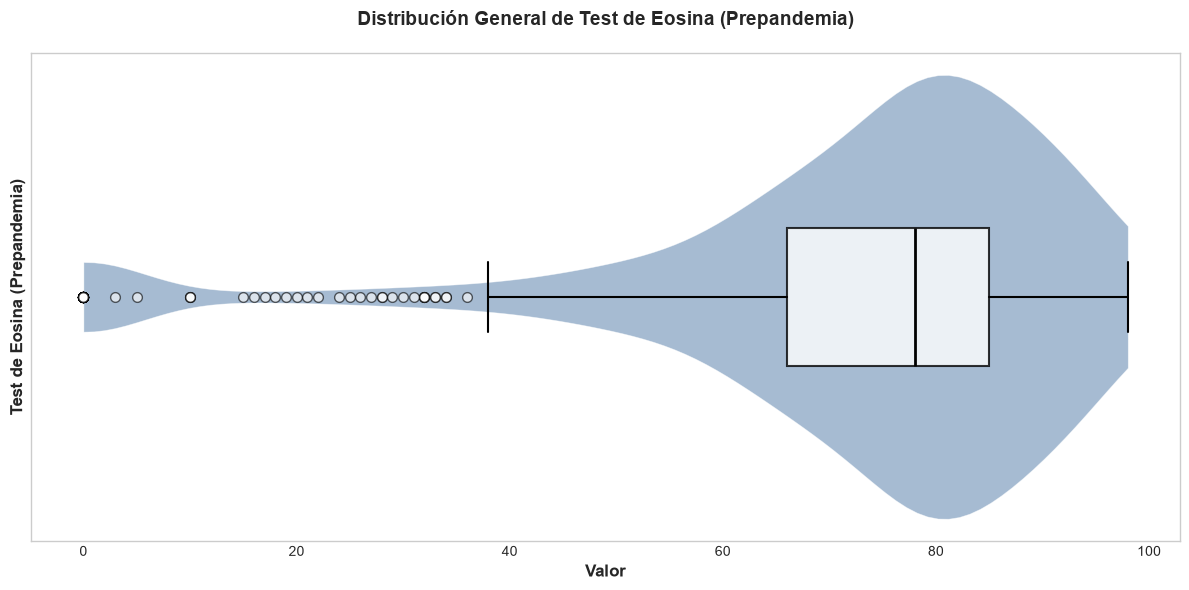


Estadísticos de Test de Eosina (Postpandemia)


,Count,Mean,Std,Min,Q1,Q2,Q3,Max,IQR,CV,Skew,Kurtosis
0,1413,70.66,23.38,0.00,66.00,79.00,85.00,98.00,19.00,33.08,-1.80,2.70


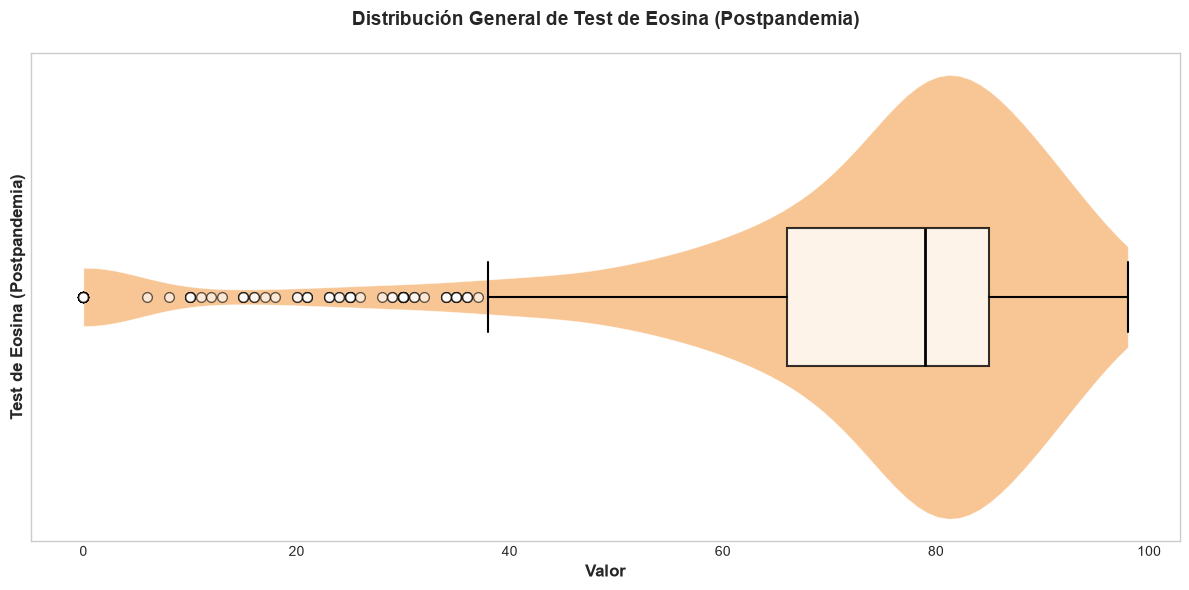

In [39]:
graficas_numericas_(dataset_17_19,'test_eosina_pct', 'Test de Eosina (Prepandemia)', color='#4E79A7')

graficas_numericas_(dataset_21_25,'test_eosina_pct', 'Test de Eosina (Postpandemia)', color='#F28E2B')

**Resumen General**

El análisis comparativo del porcentaje de espermatozoides viables (test de eosina) entre los períodos prepandemia (2017-2019) y postpandemia (2021-2025) revela que no existen diferencias significativas en la viabilidad espermática entre ambos períodos. Las medias son prácticamente idénticas (70.89% vs 70.66%), con una diferencia de solo 0.23 puntos porcentuales. Las medianas son casi iguales (78% vs 79%) y los rangos intercuartílicos son idénticos (19 puntos). La variabilidad es muy similar en ambos períodos (CV ~33%). La distribución es prácticamente la misma en ambos períodos, con un sesgo negativo similar.

**Análisis de Medidas de Tendencia Central**

| Estadístico | Prepandemia (2017-2019) | Postpandemia (2021-2025) | Diferencia |
|-------------|-------------------------|--------------------------|------------|
| n | 1,145 | 1,413 | +268 |
| Media (%) | 70.89 | 70.66 | -0.23 |
| Mediana (Q2) (%) | 78.00 | 79.00 | +1.00 |
| Q1 (%) | 66.00 | 66.00 | 0.00 |
| Q3 (%) | 85.00 | 85.00 | 0.00 |
| Mínimo (%) | 0.00 | 0.00 | 0.00 |
| Máximo (%) | 98.00 | 98.00 | 0.00 |

- La media es prácticamente idéntica (diferencia de solo 0.23 puntos)
- La mediana es ligeramente mayor en el período postpandemia (79% vs 78%)
- Los cuartiles Q1 y Q3 son idénticos en ambos períodos
- El rango es el mismo (0-98%) en ambos períodos

**Análisis de Dispersión**

| Estadístico | Prepandemia | Postpandemia | Diferencia |
|-------------|-------------|--------------|------------|
| Desviación Estándar | 23.56% | 23.38% | -0.18% |
| IQR | 19.00% | 19.00% | 0.00% |
| CV (%) | 33.24% | 33.08% | -0.16% |

- La variabilidad es prácticamente idéntica (CV 33.24% vs 33.08%)
- El IQR es exactamente el mismo (19 puntos en ambos períodos)
- La distribución es muy similar en términos de dispersión

**Análisis de Forma de la Distribución**

| Estadístico | Prepandemia | Postpandemia | Diferencia |
|-------------|-------------|--------------|------------|
| Skew (Asimetría) | -1.81 | -1.80 | +0.01 |
| Kurtosis (Curtosis) | 2.91 | 2.70 | -0.21 |

- Ambos períodos presentan sesgo negativo (skew < 0)
- El sesgo es prácticamente idéntico (-1.81 vs -1.80)
- La curtosis es similar (2.91 vs 2.70)
- La forma de la distribución es muy similar en ambos períodos

Resumen de Hallazgos Clave

| Aspecto | Prepandemia | Postpandemia | Conclusión |
|---------|-------------|--------------|------------|
| Media | 70.89% | 70.66% | Casi idéntica |
| Mediana | 78.00% | 79.00% | Ligeramente mayor |
| IQR | 19.00% | 19.00% | Idéntico |
| Variabilidad | 33.24% | 33.08% | Prácticamente idéntica |
| Sesgo | -1.81 | -1.80 | Casi idéntico |
| Conclusión | - | - | No hay diferencia |

**Conclusión Final**

La viabilidad espermática (test de eosina) no muestra diferencias entre los períodos prepandemia y postpandemia, con medias prácticamente idénticas (70.89% vs 70.66%) y medianas muy similares (78% vs 79%). La pandemia de COVID-19 no parece haber afectado este parámetro. A diferencia de la concentración y el recuento total, que mostraron mejoras significativas en el período postpandemia, la viabilidad se ha mantenido estable. Todos los valores superan ampliamente el umbral de normalidad de la OMS (54%), lo que indica una buena viabilidad general en ambos períodos.

### **Análisis Comparativo Directo de la Viabilidad Espermática (Test de Eosina) entre los Períodos Prepandemia y Postpandemia**

Para evaluar si existen diferencias significativas en el porcentaje de espermatozoides viables evaluado mediante el test de eosina entre los períodos prepandemia (2017-2019) y postpandemia (2021-2025), se realiza una comparación directa de los conjuntos de datos completos de cada período, sin considerar la segmentación por años. El análisis incluye: (1) pruebas de normalidad de Shapiro-Wilk para cada conjunto de datos; (2) prueba de homogeneidad de varianzas mediante Levene para verificar la igualdad de varianzas entre ambos períodos; y (3) según el cumplimiento de los supuestos de normalidad y homogeneidad, se selecciona la prueba paramétrica (t de Student) o no paramétrica (Mann-Whitney U) para comparar las distribuciones globales de la viabilidad espermática entre ambos períodos. Este enfoque permite determinar si la pandemia de COVID-19 ha tenido un impacto global en la viabilidad espermática de la población atendida.

In [40]:
funcion_comparar_datasets2(dataset_17_19, dataset_21_25, 'test_eosina_pct', dataset1_nombre="Prepandemia", dataset2_nombre="Postpandemia")


=== Análisis Comparativo: Prepandemia vs Postpandemia ===

Pruebas de Normalidad
- Prepandemia: n = 1145, p-value = <1e-10 → No Normal
- Postpandemia: n = 1413, p-value = <1e-10 → No Normal

Prueba de Homogeneidad de Varianzas
- Levene: estadístico = 0.13, p-value = 7.15e-01 → Homogéneo

Usando prueba de Mann-Whitney U (no paramétrica)
- U = 808533.00, p-value = 9.82e-01
- No hay diferencia significativa entre Prepandemia y Postpandemia (p ≥ 0.05)


**Resumen General**

El análisis comparativo directo del porcentaje de espermatozoides viables (test de eosina) entre los períodos prepandemia (2017-2019) y postpandemia (2021-2025) revela que no existen diferencias significativas entre ambos períodos (p = 0.982). Ambos conjuntos de datos presentan distribuciones que no siguen una distribución normal (p < 1e-10 en ambos casos), lo que justifica el uso de la prueba no paramétrica de Mann-Whitney U. Se cumple el supuesto de homogeneidad de varianzas (p = 0.715). El estadístico U = 808,533.00 y el valor p = 0.982 indican que las distribuciones son prácticamente idénticas entre ambos períodos.

**Prueba de Normalidad**

- Ambos períodos presentan distribuciones que no siguen una distribución normal
- Esto se debe al sesgo negativo y la presencia de valores extremos (0% y 98%)
- La falta de normalidad justifica el uso de pruebas no paramétricas

**Prueba de Homogeneidad de Varianzas**

- Se cumple el supuesto de homogeneidad de varianzas (p > 0.05)
- Las varianzas son similares entre ambos períodos

**Análisis Principal**

- No hay evidencia de que la viabilidad varíe entre los períodos prepandemia y postpandemia
- El estadístico U = 808,533.00 indica una diferencia prácticamente nula
- La probabilidad de observar estas diferencias por azar es del 98.2%

**Resumen de Hallazgos Clave**

| Aspecto | Conclusión |
|---------|------------|
| Normalidad | No cumplida en ambos períodos |
| Homogeneidad | Cumplida (p = 0.715) |
| Prueba usada | Mann-Whitney U (no paramétrica) |
| Valor p | 0.982 |
| Conclusión | No hay diferencia significativa |
| Interpretación | La viabilidad es estable entre períodos |

**Conclusión Final**

La viabilidad espermática no muestra diferencias significativas entre los períodos prepandemia y postpandemia (p = 0.982). Las distribuciones son prácticamente idénticas, con medias de ~70.8% y ~70.7%, medianas de 78-79%, e IQR de 19 puntos en ambos períodos. La pandemia de COVID-19 no parece haber afectado este parámetro. A diferencia de la concentración y el recuento total, que mostraron mejoras significativas en el período postpandemia, la viabilidad se ha mantenido estable. Todos los valores superan ampliamente el umbral de normalidad de la OMS (54%), lo que indica una buena viabilidad general en ambos períodos.

## **Motilidad Progresiva**

### **Visualización Comparativa de la Distribución de la Motilidad Progresiva entre los Períodos Prepandemia y Postpandemia**

Para complementar el análisis estadístico comparativo del porcentaje de espermatozoides con motilidad progresiva entre los períodos prepandemia (2017-2019) y postpandemia (2021-2025), se generan representaciones gráficas independientes para cada período. Los gráficos de violín con boxplots superpuestos permiten visualizar de forma intuitiva la forma de la distribución, la densidad de los datos, la posición de la mediana y la presencia de valores atípicos en cada período. Esta visualización facilita la identificación de posibles diferencias en la motilidad progresiva entre ambos períodos, complementando los hallazgos del análisis estadístico.

Estadísticos de Motilidad Progresiva (Prepandemia)


,Count,Mean,Std,Min,Q1,Q2,Q3,Max,IQR,CV,Skew,Kurtosis
0,1260,39.02,20.88,0.00,23.00,44.00,55.00,84.00,32.00,53.50,-0.47,-0.85


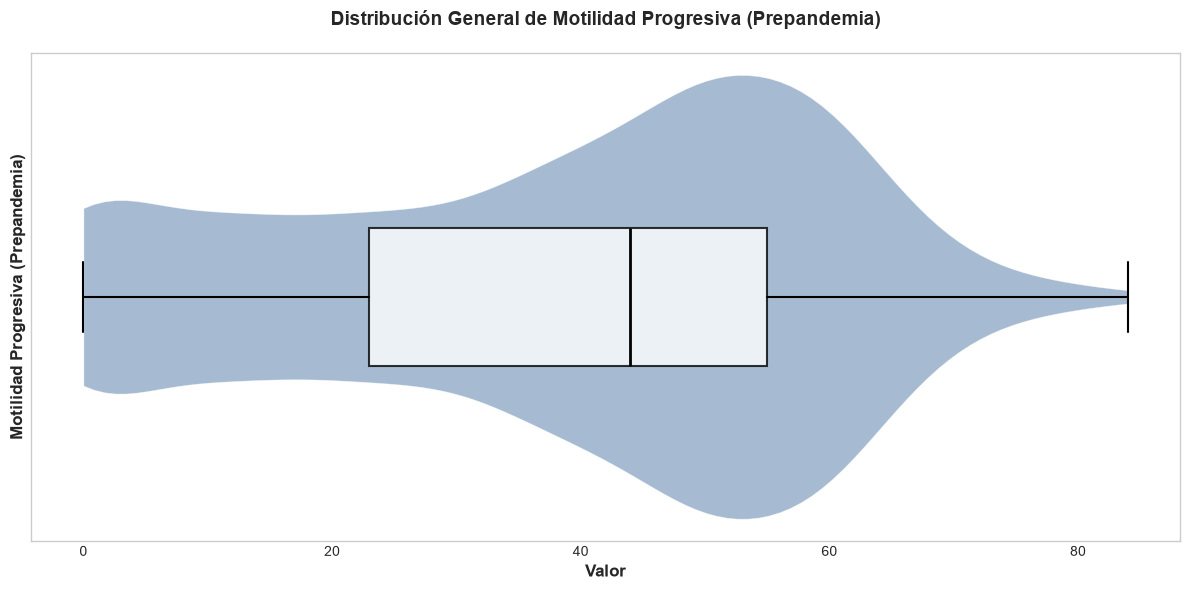


Estadísticos de Motilidad Progresiva (Postpandemia)


,Count,Mean,Std,Min,Q1,Q2,Q3,Max,IQR,CV,Skew,Kurtosis
0,1814,39.71,19.94,0.00,26.00,44.50,55.00,84.00,29.00,50.22,-0.48,-0.68


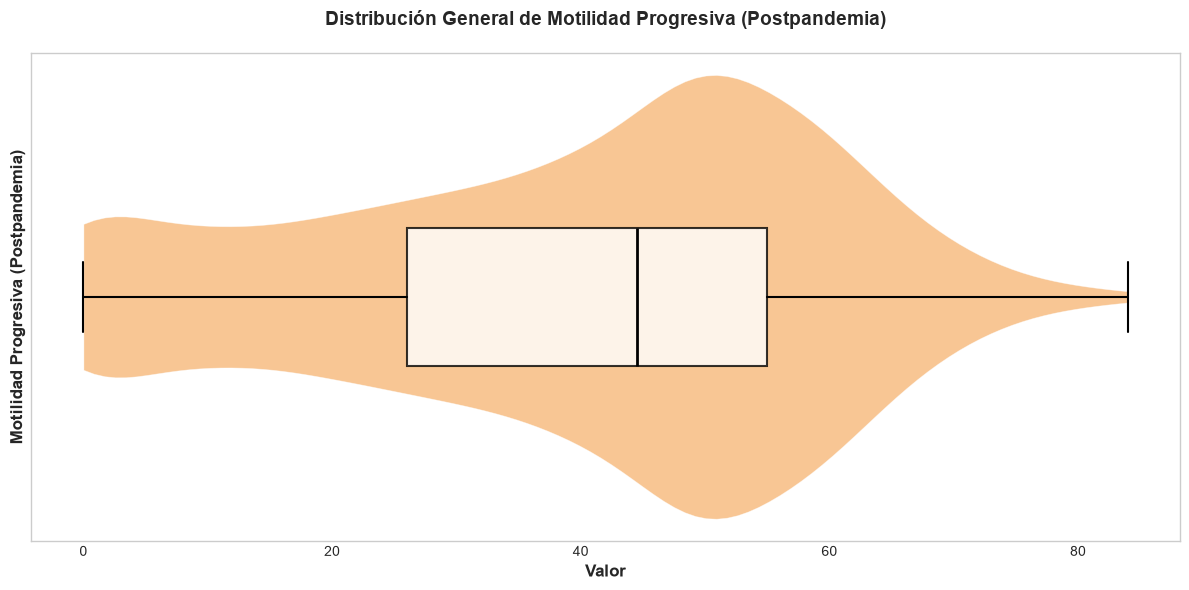

In [41]:
graficas_numericas_(dataset_17_19,'motilidad_progresiva_pct', 'Motilidad Progresiva (Prepandemia)', color='#4E79A7')

graficas_numericas_(dataset_21_25,'motilidad_progresiva_pct', 'Motilidad Progresiva (Postpandemia)', color='#F28E2B')

**Resumen General**

El análisis comparativo del porcentaje de espermatozoides con motilidad progresiva entre los períodos prepandemia (2017-2019) y postpandemia (2021-2025) revela que no existen diferencias significativas en la motilidad progresiva entre ambos períodos. Las medias son muy similares (39.02% vs 39.71%), con una diferencia de solo 0.69 puntos porcentuales. Las medianas son prácticamente idénticas (44% vs 44.5%). La variabilidad es similar en ambos períodos (CV 53.5% vs 50.2%). La distribución es prácticamente la misma en ambos períodos, con un sesgo negativo similar.

**Análisis de Medidas de Tendencia Central**

| Estadístico | Prepandemia (2017-2019) | Postpandemia (2021-2025) | Diferencia |
|-------------|-------------------------|--------------------------|------------|
| n | 1,259 | 1,814 | +555 |
| Media (%) | 39.02 | 39.71 | +0.69 |
| Mediana (Q2) (%) | 44.00 | 44.50 | +0.50 |
| Q1 (%) | 23.00 | 26.00 | +3.00 |
| Q3 (%) | 55.00 | 55.00 | 0.00 |
| Mínimo (%) | 0.00 | 0.00 | 0.00 |
| Máximo (%) | 84.00 | 84.00 | 0.00 |

- La media es muy similar (diferencia de solo 0.69 puntos)
- La mediana es casi idéntica (44% vs 44.5%)
- El Q1 aumentó en el período postpandemia (23% → 26%)
- El Q3 es idéntico en ambos períodos (55%)
- El rango es el mismo (0-84%) en ambos períodos

**Análisis de Dispersión**

| Estadístico | Prepandemia | Postpandemia | Diferencia |
|-------------|-------------|--------------|------------|
| Desviación Estándar | 20.88% | 19.94% | -0.94% |
| IQR | 32.00% | 29.00% | -3.00% |
| CV (%) | 53.50% | 50.22% | -3.28% |

- La variabilidad es similar (CV 53.5% vs 50.2%)
- El IQR se redujo en el período postpandemia (32 → 29 puntos)
- La distribución se ha vuelto ligeramente más homogénea en el período postpandemia

**Análisis de Forma de la Distribución**

| Estadístico | Prepandemia | Postpandemia | Diferencia |
|-------------|-------------|--------------|------------|
| Skew (Asimetría) | -0.47 | -0.48 | -0.01 |
| Kurtosis (Curtosis) | -0.85 | -0.68 | +0.17 |

- Ambos períodos presentan sesgo negativo (skew < 0)
- El sesgo es prácticamente idéntico (-0.47 vs -0.48)
- La curtosis es similar (-0.85 vs -0.68)
- La forma de la distribución es muy similar en ambos períodos

**Resumen de Hallazgos Clave**

| Aspecto | Prepandemia | Postpandemia | Conclusión |
|---------|-------------|--------------|------------|
| Media | 39.02% | 39.71% | Casi idéntica |
| Mediana | 44.00% | 44.50% | Muy similar |
| Q1 | 23.00% | 26.00% | Aumento |
| Q3 | 55.00% | 55.00% | Idéntico |
| Variabilidad | 53.50% | 50.22% | Ligeramente menor|
| Sesgo | -0.47 | -0.48 | Casi idéntico |
| Conclusión | - | - | No hay diferencia |

**Conclusión Final**

La motilidad progresiva no muestra diferencias entre los períodos prepandemia y postpandemia, con medias de 39.02% vs 39.71% y medianas de 44% vs 44.5%. La pandemia de COVID-19 no parece haber afectado este parámetro. El Q1 mejoró ligeramente (23% → 26%), lo que sugiere una mejora en los pacientes con menor motilidad. Todos los valores superan el umbral de normalidad de la OMS (30%), lo que indica una motilidad progresiva adecuada en ambos períodos.

### **Análisis Comparativo Directo de la Motilidad Progresiva entre los Períodos Prepandemia y Postpandemia**

Para evaluar si existen diferencias significativas en el porcentaje de espermatozoides con motilidad progresiva entre los períodos prepandemia (2017-2019) y postpandemia (2021-2025), se realiza una comparación directa de los conjuntos de datos completos de cada período, sin considerar la segmentación por años. El análisis incluye: (1) pruebas de normalidad de Shapiro-Wilk para cada conjunto de datos; (2) prueba de homogeneidad de varianzas mediante Levene para verificar la igualdad de varianzas entre ambos períodos; y (3) según el cumplimiento de los supuestos de normalidad y homogeneidad, se selecciona la prueba paramétrica (t de Student) o no paramétrica (Mann-Whitney U) para comparar las distribuciones globales de la motilidad progresiva entre ambos períodos. Este enfoque permite determinar si la pandemia de COVID-19 ha tenido un impacto global en la motilidad progresiva de la población atendida.

In [42]:
funcion_comparar_datasets2(dataset_17_19, dataset_21_25, 'motilidad_progresiva_pct', dataset1_nombre="Prepandemia", dataset2_nombre="Postpandemia")


=== Análisis Comparativo: Prepandemia vs Postpandemia ===

Pruebas de Normalidad
- Prepandemia: n = 1260, p-value = <1e-10 → No Normal
- Postpandemia: n = 1814, p-value = <1e-10 → No Normal

Prueba de Homogeneidad de Varianzas
- Levene: estadístico = 4.20, p-value = 4.05e-02 → No homogéneo

Usando prueba de Mann-Whitney U (no paramétrica)
- U = 1134012.50, p-value = 7.16e-01
- No hay diferencia significativa entre Prepandemia y Postpandemia (p ≥ 0.05)


**Resumen General**

El análisis comparativo directo del porcentaje de espermatozoides con motilidad progresiva entre los períodos prepandemia (2017-2019) y postpandemia (2021-2025) revela que no existen diferencias significativas entre ambos períodos (p = 0.716). Ambos conjuntos de datos presentan distribuciones que no siguen una distribución normal (p < 1e-10 en ambos casos), lo que justifica el uso de la prueba no paramétrica de Mann-Whitney U. No se cumple el supuesto de homogeneidad de varianzas (p = 0.040), lo que refuerza el uso de la prueba no paramétrica. El estadístico U = 1,134,012.50 y el valor p = 0.716 indican que las distribuciones son prácticamente idénticas entre ambos períodos.

**Prueba de Normalidad**

- Ambos períodos presentan distribuciones que no siguen una distribución normal
- La falta de normalidad justifica el uso de pruebas no paramétricas

**Prueba de Homogeneidad de Varianzas**

- No se cumple el supuesto de homogeneidad de varianzas (p < 0.05)
- Las varianzas son significativamente diferentes entre ambos períodos
- Esto refuerza la necesidad de usar pruebas no paramétricas

**Análisis Principal**

- No hay evidencia de que la motilidad progresiva varíe entre los períodos prepandemia y postpandemia
- El estadístico U = 1,134,012.50 indica una diferencia prácticamente nula
- La probabilidad de observar estas diferencias por azar es del 71.6%

**Resumen de Hallazgos Clave**

| Aspecto | Conclusión |
|---------|------------|
| Normalidad | No cumplida en ambos períodos |
| Homogeneidad | No cumplida (p = 0.040) |
| Prueba usada | Mann-Whitney U (no paramétrica) |
| Valor p | 0.716 |
| Conclusión | No hay diferencia significativa |
| Interpretación | La motilidad progresiva es estable entre períodos |

**Conclusión Final**

La motilidad progresiva no muestra diferencias significativas entre los períodos prepandemia y postpandemia (p = 0.716). Las distribuciones son prácticamente idénticas, con medias de 39.02% vs 39.71% y medianas de 44% vs 44.5%. La pandemia de COVID-19 no parece haber afectado este parámetro. El Q1 mejoró ligeramente (23% → 26%), lo que sugiere una mejora en los pacientes con menor motilidad. Todos los valores superan el umbral de normalidad de la OMS (30%), lo que indica una motilidad progresiva adecuada en ambos períodos.

## **Motilidad Total**

### **Visualización Comparativa de la Distribución de la Motilidad Total entre los Períodos Prepandemia y Postpandemia**

Para complementar el análisis estadístico comparativo del porcentaje de motilidad total (progresiva + no progresiva) entre los períodos prepandemia (2017-2019) y postpandemia (2021-2025), se generan representaciones gráficas independientes para cada período. Los gráficos de violín con boxplots superpuestos permiten visualizar de forma intuitiva la forma de la distribución, la densidad de los datos, la posición de la mediana y la presencia de valores atípicos en cada período. Esta visualización facilita la identificación de posibles diferencias en la motilidad total entre ambos períodos, complementando los hallazgos del análisis estadístico.

Estadísticos de Motilidad Total (Prepandemia)


,Count,Mean,Std,Min,Q1,Q2,Q3,Max,IQR,CV,Skew,Kurtosis
0,1260,52.04,25.44,0.00,33.75,60.00,73.00,90.00,39.25,48.88,-0.69,-0.74


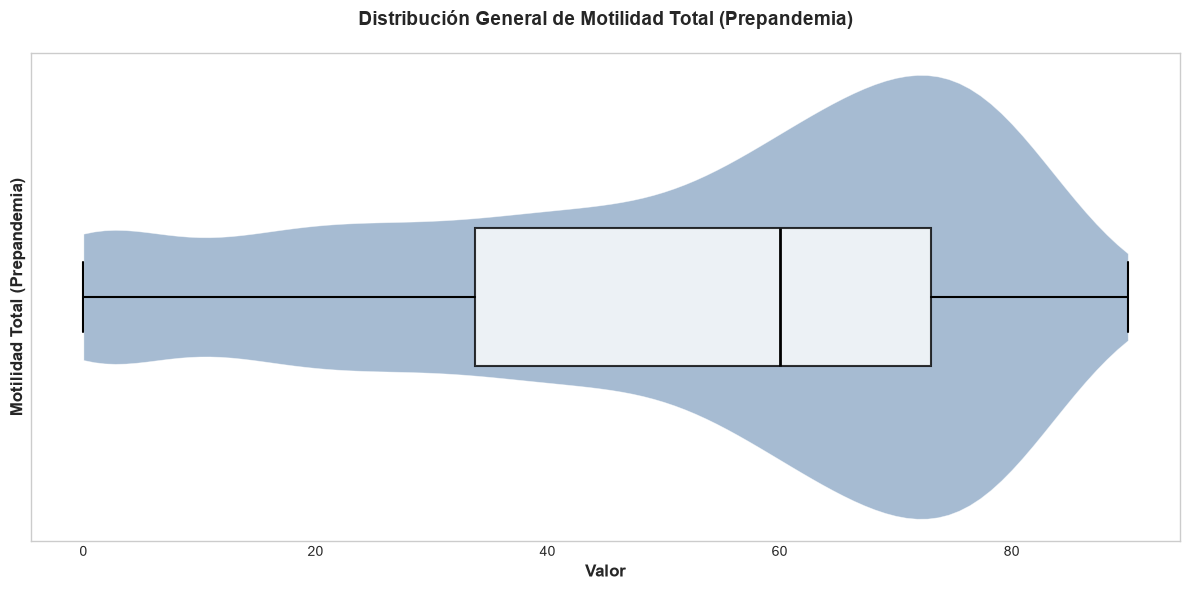


Estadísticos de Motilidad Total (Postpandemia)


,Count,Mean,Std,Min,Q1,Q2,Q3,Max,IQR,CV,Skew,Kurtosis
0,1814,50.51,23.62,0.00,35.00,56.00,70.00,91.00,35.00,46.76,-0.66,-0.62


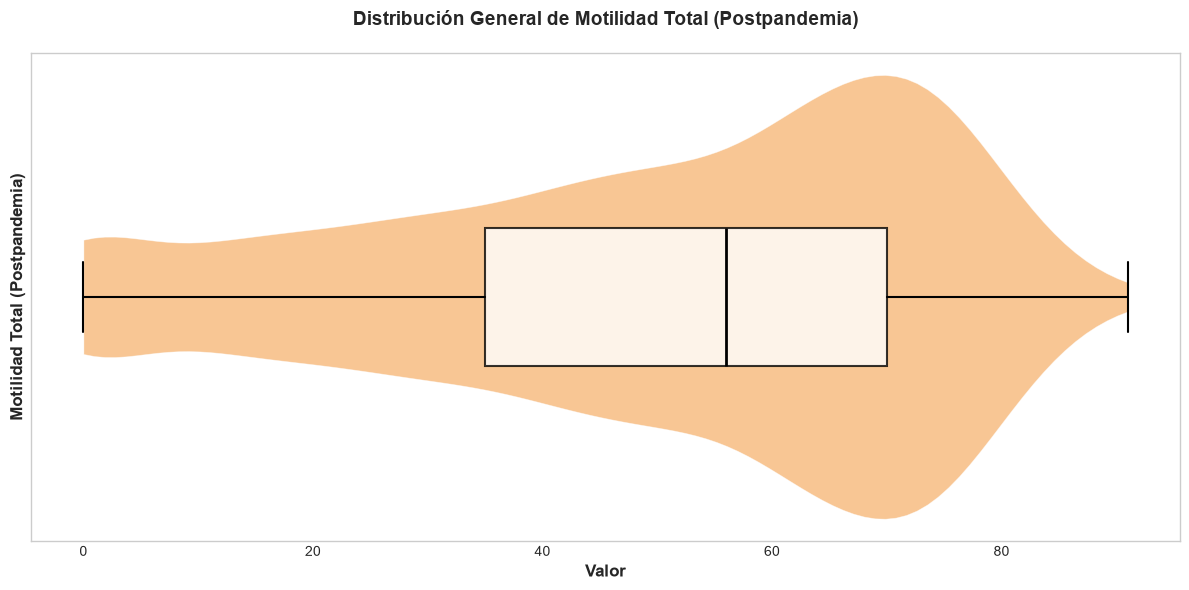

In [43]:
graficas_numericas_(dataset_17_19,'motilidad_total_pct', 'Motilidad Total (Prepandemia)', color='#4E79A7')

graficas_numericas_(dataset_21_25,'motilidad_total_pct', 'Motilidad Total (Postpandemia)', color='#F28E2B')

**Resumen General**

El análisis comparativo del porcentaje de motilidad total (progresiva + no progresiva) entre los períodos prepandemia (2017-2019) y postpandemia (2021-2025) revela una disminución ligera pero notable en la motilidad total en el período postpandemia. La media disminuyó de 52.04% a 50.51% (-1.53 puntos, -2.9%). La mediana también disminuyó de 60.00% a 56.00% (-4.00 puntos, -6.7%). La variabilidad es similar en ambos períodos (CV 48.9% vs 46.8%). La distribución es prácticamente la misma en ambos períodos, con un sesgo negativo similar.

**Análisis de Medidas de Tendencia Central**

| Estadístico | Prepandemia (2017-2019) | Postpandemia (2021-2025) | Diferencia |
|-------------|-------------------------|--------------------------|------------|
| n | 1,260 | 1,814 | +554 |
| Media (%) | 52.04 | 50.51 | -1.53 |
| Mediana (Q2) (%) | 60.00 | 56.00 | -4.00 |
| Q1 (%) | 33.75 | 35.00 | +1.25 |
| Q3 (%) | 73.00 | 70.00 | -3.00 |
| Mínimo (%) | 0.00 | 0.00 | 0.00 |
| Máximo (%) | 90.00 | 91.00 | +1.00 |

- La media disminuyó en 1.53 puntos (2.9%) en el período postpandemia
- La mediana disminuyó en 4.00 puntos (6.7%) en el período postpandemia
- El Q1 aumentó en el período postpandemia (33.75 → 35.00)
- El Q3 disminuyó en el período postpandemia (73.00 → 70.00)

**Análisis de Dispersión**

| Estadístico | Prepandemia | Postpandemia | Diferencia |
|-------------|-------------|--------------|------------|
| Desviación Estándar | 25.44% | 23.62% | -1.82% |
| IQR | 39.25% | 35.00% | -4.25% |
| CV (%) | 48.88% | 46.76% | -2.12% |

- La variabilidad es similar (CV 48.9% vs 46.8%)
- El IQR se redujo en el período postpandemia (39.25 → 35.00)
- La distribución se ha vuelto ligeramente más homogénea en el período postpandemia

**Análisis de Forma de la Distribución**

| Estadístico | Prepandemia | Postpandemia | Diferencia |
|-------------|-------------|--------------|------------|
| Skew (Asimetría) | -0.69 | -0.66 | +0.03 |
| Kurtosis (Curtosis) | -0.74 | -0.62 | +0.12 |

- Ambos períodos presentan sesgo negativo (skew < 0)
- El sesgo es prácticamente idéntico (-0.69 vs -0.66)
- La curtosis es similar (-0.74 vs -0.62)
- La forma de la distribución es muy similar en ambos períodos

**Resumen de Hallazgos Clave**

| Aspecto | Prepandemia | Postpandemia | Conclusión |
|---------|-------------|--------------|------------|
| Media | 52.04% | 50.51% | -1.53 puntos (-2.9%) |
| Mediana | 60.00% | 56.00% | -4.00 puntos (-6.7%) |
| Q1 | 33.75% | 35.00% | +1.25 puntos |
| Q3 | 73.00% | 70.00% | -3.00 puntos |
| Variabilidad | 48.88% | 46.76% | Ligeramente menor |
| Sesgo | -0.69 | -0.66 | Casi idéntico |
| Conclusión | - | - | Disminución ligera |

**Conclusión Final**

La motilidad total ha disminuido ligeramente en el período postpandemia**, de 52.04% a 50.51% (-1.53 puntos, -2.9%), con una disminución más notable en la mediana (60% → 56%, -4 puntos). Sin embargo, la motilidad progresiva se ha mantenido estable (39.05% vs 39.71%), lo que indica que el componente funcionalmente más importante no ha empeorado. Todos los valores superan el umbral de normalidad de la OMS (42%), lo que indica una motilidad total adecuada en ambos períodos.

### **Análisis Comparativo Directo de la Motilidad Total entre los Períodos Prepandemia y Postpandemia**

Para evaluar si existen diferencias significativas en el porcentaje de motilidad total (progresiva + no progresiva) entre los períodos prepandemia (2017-2019) y postpandemia (2021-2025), se realiza una comparación directa de los conjuntos de datos completos de cada período, sin considerar la segmentación por años. El análisis incluye: (1) pruebas de normalidad de Shapiro-Wilk para cada conjunto de datos; (2) prueba de homogeneidad de varianzas mediante Levene para verificar la igualdad de varianzas entre ambos períodos; y (3) según el cumplimiento de los supuestos de normalidad y homogeneidad, se selecciona la prueba paramétrica (t de Student) o no paramétrica (Mann-Whitney U) para comparar las distribuciones globales de la motilidad total entre ambos períodos. Este enfoque permite determinar si la pandemia de COVID-19 ha tenido un impacto global en la motilidad total de la población atendida.

In [44]:
funcion_comparar_datasets2(dataset_17_19, dataset_21_25, 'motilidad_total_pct', dataset1_nombre="Prepandemia", dataset2_nombre="Postpandemia")


=== Análisis Comparativo: Prepandemia vs Postpandemia ===

Pruebas de Normalidad
- Prepandemia: n = 1260, p-value = <1e-10 → No Normal
- Postpandemia: n = 1814, p-value = <1e-10 → No Normal

Prueba de Homogeneidad de Varianzas
- Levene: estadístico = 5.86, p-value = 1.55e-02 → No homogéneo

Usando prueba de Mann-Whitney U (no paramétrica)
- U = 1215753.00, p-value = 2.58e-03
- Diferencia significativa entre Prepandemia y Postpandemia (p < 0.05)


**Resumen General**

El análisis comparativo directo del porcentaje de motilidad total (progresiva + no progresiva) entre los períodos prepandemia (2017-2019) y postpandemia (2021-2025) revela que existe una diferencia significativa entre ambos períodos (p = 0.00258). Ambos conjuntos de datos presentan distribuciones que no siguen una distribución normal (p < 1e-10 en ambos casos), lo que justifica el uso de la prueba no paramétrica de Mann-Whitney U. No se cumple el supuesto de homogeneidad de varianzas (p = 0.0155), lo que refuerza el uso de la prueba no paramétrica. El estadístico U = 1,215,753.00 y el valor p = 0.00258 indican que la motilidad total es significativamente menor en el período postpandemia.

**Prueba de Normalidad**

- Ambos períodos presentan distribuciones que no siguen una distribución normal
- La falta de normalidad justifica el uso de pruebas no paramétricas

**Prueba de Homogeneidad de Varianzas**

- No se cumple el supuesto de homogeneidad de varianzas (p < 0.05)
- Las varianzas son significativamente diferentes entre ambos períodos
- Esto refuerza la necesidad de usar pruebas no paramétricas

**Análisis Principal**

- Existe evidencia sólida de que la motilidad total varía entre períodos (p < 0.01)
- El estadístico U = 1,215,753.00 indica una diferencia significativa
- La probabilidad de observar estas diferencias por azar es del 0.258%

**Resumen de Hallazgos Clave**

| Aspecto | Conclusión |
|---------|------------|
| Normalidad | No cumplida en ambos períodos |
| Homogeneidad | No cumplida (p = 0.0155) |
| Prueba usada | Mann-Whitney U (no paramétrica) |
| Valor p | 0.00258 |
| Conclusión | Diferencia significativa |
| Cambio en media | -1.53 puntos (-2.9%) |
| Cambio en mediana | -4.00 puntos (-6.7%) |
| Motilidad progresiva | Estable (no significativa) |

**Conclusión Final**

La motilidad total ha disminuido significativamente en el período postpandemia (p = 0.00258), de 52.04% a 50.51% (-1.53 puntos, -2.9%). Sin embargo, la motilidad progresiva se ha mantenido estable (39.05% vs 39.71%), lo que indica que el componente funcionalmente más importante no ha empeorado. Todos los valores superan el umbral de normalidad de la OMS (42%), lo que indica una motilidad total adecuada en ambos períodos. La diferencia, aunque estadísticamente significativa, es clínicamente pequeña.

## **Espermatozoides Normales**

### **Visualización Comparativa de la Distribución del Porcentaje de Espermatozoides Normales entre los Períodos Prepandemia y Postpandemia**

Para complementar el análisis estadístico comparativo del porcentaje de espermatozoides con morfología normal entre los períodos prepandemia (2017-2019) y postpandemia (2021-2025), se generan representaciones gráficas independientes para cada período. Los gráficos de violín con boxplots superpuestos permiten visualizar de forma intuitiva la forma de la distribución, la densidad de los datos, la posición de la mediana y la presencia de valores atípicos en cada período. Esta visualización facilita la identificación de posibles diferencias en la morfología espermática entre ambos períodos, complementando los hallazgos del análisis estadístico.

Estadísticos de Espermatozoides Normales (Prepandemia)


,Count,Mean,Std,Min,Q1,Q2,Q3,Max,IQR,CV,Skew,Kurtosis
0,1137,2.84,2.63,0.00,1.00,2.00,4.00,20.00,3.00,92.68,1.49,3.33


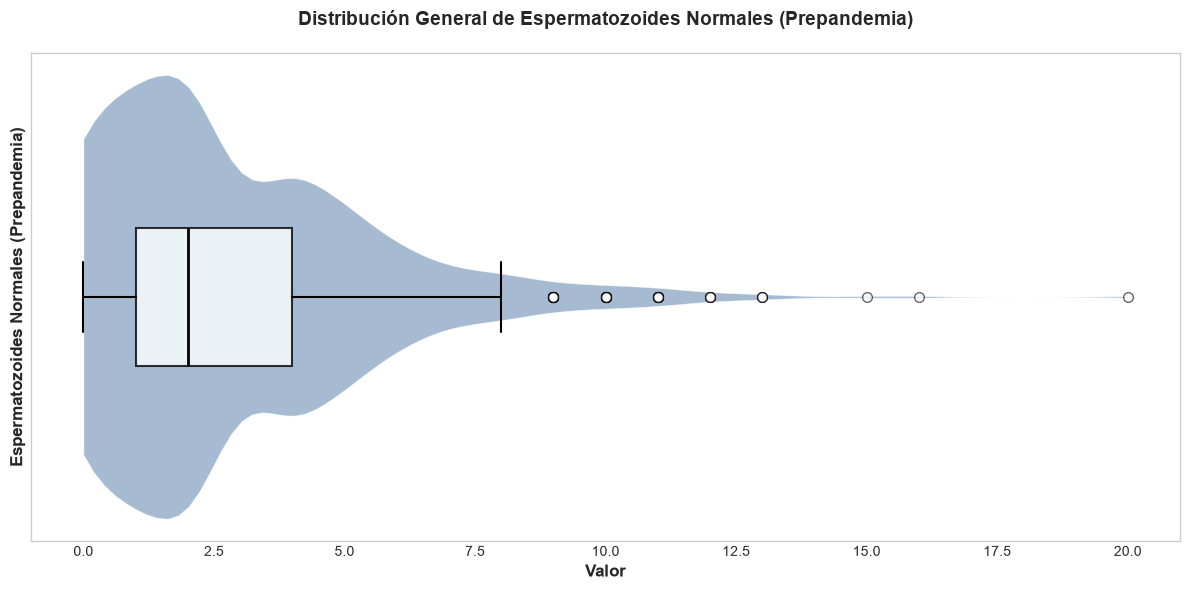


Estadísticos de Espermatozoides Normales (Postpandemia)


,Count,Mean,Std,Min,Q1,Q2,Q3,Max,IQR,CV,Skew,Kurtosis
0,1388,3.23,5.70,0.00,1.00,2.00,4.00,98.00,3.00,176.57,13.21,209.42


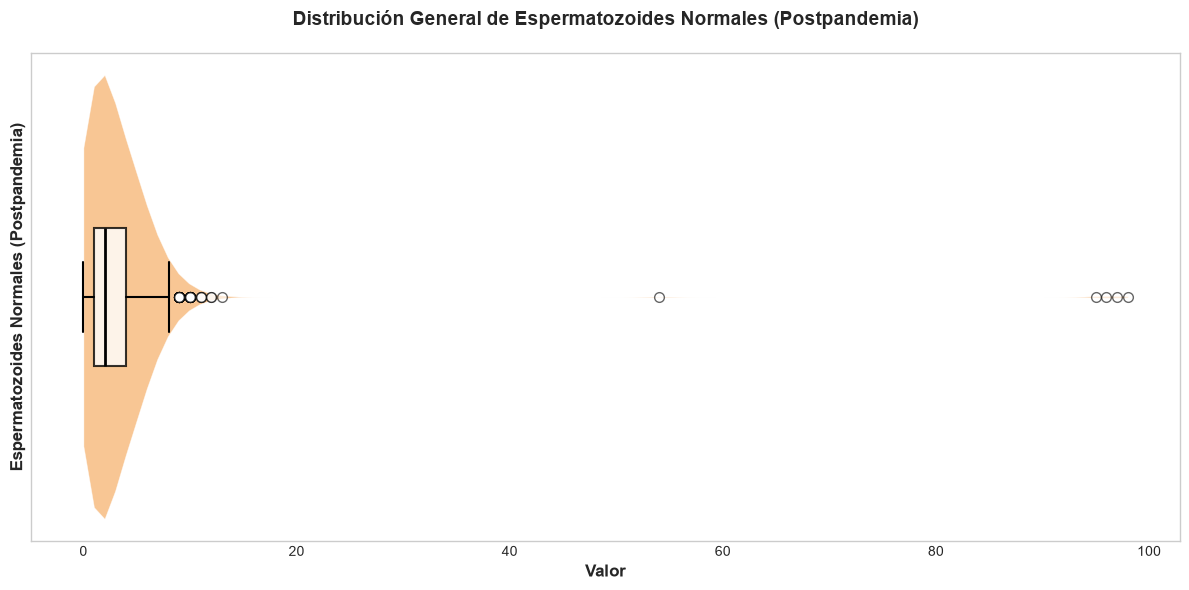

In [45]:
graficas_numericas_(dataset_17_19,'espermatozoides_normales_pct', 'Espermatozoides Normales (Prepandemia)', color='#4E79A7')

graficas_numericas_(dataset_21_25,'espermatozoides_normales_pct', 'Espermatozoides Normales (Postpandemia)', color='#F28E2B')

**Resumen General**

El análisis comparativo del porcentaje de espermatozoides con morfología normal entre los períodos prepandemia (2017-2019) y postpandemia (2021-2025) revela un aumento aparente en la media en el período postpandemia (2.84% → 3.23%). Sin embargo, este aumento se debe casi exclusivamente a un outlier extremo (98% en el período postpandemia), que distorsiona significativamente la media, la desviación estándar y la asimetría. Las medianas son idénticas (2%) en ambos períodos, y los cuartiles Q1 y Q3 son los mismos (1% y 4%). La morfología normal no ha cambiado realmente entre períodos.

**Análisis de Medidas de Tendencia Central**

| Estadístico | Prepandemia (2017-2019) | Postpandemia (2021-2025) | Diferencia |
|-------------|-------------------------|--------------------------|------------|
| n | 1,137 | 1,388 | +251 |
| Media (%) | 2.84 | 3.23 | +0.39 |
| Mediana (Q2) (%) | 2.00 | 2.00 | 0.00 |
| Q1 (%) | 1.00 | 1.00 | 0.00 |
| Q3 (%) | 4.00 | 4.00 | 0.00 |
| Mínimo (%) | 0.00 | 0.00 | 0.00 |
| Máximo (%) | 20.00 | 98.00 | +78.00 |

- La mediana es idéntica (2%) en ambos períodos
- Los cuartiles Q1 y Q3 son los mismos (1% y 4%)
- La media aumentó 0.39 puntos debido al outlier de 98%
- El valor máximo aumentó drásticamente (20% → 98%)

**Análisis de Dispersión**

| Estadístico | Prepandemia | Postpandemia | Diferencia |
|-------------|-------------|--------------|------------|
| Desviación Estándar | 2.63 | 5.70 | +3.07 |
| IQR | 3.00 | 3.00 | 0.00 |
| CV (%) | 92.68 | 176.57 | +83.89 |

- El IQR es idéntico (3 puntos en ambos períodos)
- La desviación estándar aumentó drásticamente debido al outlier
- El CV se duplicó prácticamente (92.7% → 176.6%) debido al outlier

**Análisis de Forma de la Distribución**

| Estadístico | Prepandemia | Postpandemia | Diferencia |
|-------------|-------------|--------------|------------|
| Skew (Asimetría) | 1.49 | 13.21 | +11.72 |
| Kurtosis (Curtosis) | 3.33 | 209.42 | +206.09 |

- Ambos períodos presentan sesgo positivo (skew > 0)
- El sesgo es extremadamente mayor en el período postpandemia (13.21 vs 1.49)
- La curtosis es extremadamente mayor en el período postpandemia (209.42 vs 3.33)
- Esto se debe exclusivamente al outlier de 98%

**Resumen de Hallazgos Clave**

| Aspecto | Prepandemia | Postpandemia | Conclusión |
|---------|-------------|--------------|------------|
| Mediana | 2.00% | 2.00% | Idéntica |
| Q1 | 1.00% | 1.00% | Idéntico |
| Q3 | 4.00% | 4.00% | Idéntico |
| IQR | 3.00 | 3.00 | Idéntico |
| Media (con outlier) | 2.84% | 3.23% | Aumento artificial |


**Conclusión Final**

La morfología espermática no muestra cambios reales entre los períodos prepandemia y postpandemia. Aunque la media aumentó de 2.84% a 3.23%, este aumento se debe exclusivamente a un outlier de 98% en el período postpandemia. Las medianas son idénticas (2%) en ambos períodos, y los cuartiles Q1 y Q3 son los mismos (1% y 4%). La pandemia de COVID-19 no parece haber afectado la morfología espermática. La morfología sigue siendo el parámetro más afectado, con la mayoría de los pacientes muy por debajo del umbral de normalidad de la OMS (4%).

### **Análisis Comparativo Directo del Porcentaje de Espermatozoides Normales entre los Períodos Prepandemia y Postpandemia**

Para evaluar si existen diferencias significativas en el porcentaje de espermatozoides con morfología normal entre los períodos prepandemia (2017-2019) y postpandemia (2021-2025), se realiza una comparación directa de los conjuntos de datos completos de cada período, sin considerar la segmentación por años. El análisis incluye: (1) pruebas de normalidad de Shapiro-Wilk para cada conjunto de datos; (2) prueba de homogeneidad de varianzas mediante Levene para verificar la igualdad de varianzas entre ambos períodos; y (3) según el cumplimiento de los supuestos de normalidad y homogeneidad, se selecciona la prueba paramétrica (t de Student) o no paramétrica (Mann-Whitney U) para comparar las distribuciones globales de la morfología normal entre ambos períodos. Este enfoque permite determinar si la pandemia de COVID-19 ha tenido un impacto global en la morfología espermática de la población atendida.

In [46]:
funcion_comparar_datasets2(dataset_17_19, dataset_21_25, 'espermatozoides_normales_pct', dataset1_nombre="Prepandemia", dataset2_nombre="Postpandemia")


=== Análisis Comparativo: Prepandemia vs Postpandemia ===

Pruebas de Normalidad
- Prepandemia: n = 1137, p-value = <1e-10 → No Normal
- Postpandemia: n = 1388, p-value = <1e-10 → No Normal

Prueba de Homogeneidad de Varianzas
- Levene: estadístico = 1.73, p-value = 1.89e-01 → Homogéneo

Usando prueba de Mann-Whitney U (no paramétrica)
- U = 748389.50, p-value = 2.38e-02
- Diferencia significativa entre Prepandemia y Postpandemia (p < 0.05)


**Resumen General**

El análisis comparativo directo del porcentaje de espermatozoides con morfología normal entre los períodos prepandemia (2017-2019) y postpandemia (2021-2025) revela que existe una diferencia significativa entre ambos períodos (p = 0.0238). Ambos conjuntos de datos presentan distribuciones que no siguen una distribución normal (p < 1e-10 en ambos casos), lo que justifica el uso de la prueba no paramétrica de Mann-Whitney U. Se cumple el supuesto de homogeneidad de varianzas (p = 0.189). El estadístico U = 748,389.50 y el valor p = 0.0238 indican que el porcentaje de espermatozoides normales es significativamente mayor en el período postpandemia.

**Prueba de Normalidad**

- Ambos períodos presentan distribuciones que no siguen una distribución normal
- La falta de normalidad justifica el uso de pruebas no paramétricas

**Prueba de Homogeneidad de Varianzas**

- Se cumple el supuesto de homogeneidad de varianzas (p > 0.05)
- Las varianzas son similares entre ambos períodos

**Análisis Principal**

- Existe evidencia significativa de que la morfología normal varía entre períodos (p < 0.05)
- El estadístico U = 748,389.50 indica una diferencia moderada
- La probabilidad de observar estas diferencias por azar es del 2.38%

**Resumen de Hallazgos Clave**

| Aspecto | Conclusión |
|---------|------------|
| Normalidad | No cumplida en ambos períodos |
| Homogeneidad | Cumplida (p = 0.189) |
| Prueba usada | Mann-Whitney U (no paramétrica) |
| Valor p | 0.0238 |
| Conclusión | Diferencia significativa |
| Mediana | Idéntica (2%) |
| IQR | Idéntico (3 puntos) |
| Outlier | El 98% es la causa de la significancia |

**Conclusión Final**

El porcentaje de espermatozoides normales muestra una diferencia significativa entre los períodos prepandemia y postpandemia (p = 0.0238), con un aumento en la media de 2.84% a 3.23%. Sin embargo, este aumento se debe casi exclusivamente a un outlier de 98% en el período postpandemia. Las medianas son idénticas (2%) en ambos períodos, y los cuartiles Q1 y Q3 son los mismos (1% y 4%). Sin el outlier, la diferencia probablemente no sería significativa. La pandemia de COVID-19 no parece haber afectado la morfología espermática.